#MAPEO DE SERIES DE TIEMPO DE ANOMALÍAS DE ENOS Y CAUDAL

##DEFINICIONES

In [1]:
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt


# ============================================================
# Mapeo global de permutaciones (predefinido para w=4)
# ============================================================

# Generar todas las permutaciones posibles de (1,2,3,4)
w_fijo = 4
permutaciones = list(itertools.permutations(range(1, w_fijo+1)))
permutaciones.sort()  # Orden lexicográfico para consistencia

# Crear mapeos globales
MAQUINA_ESTADOS = {perm: idx for idx, perm in enumerate(permutaciones)}  # perm -> índice 0-23
INDICE_A_PERM = {idx: perm for idx, perm in enumerate(permutaciones)}  # índice -> perm
NUM_NODOS_GLOBAL = len(permutaciones)  # 24

# ============================================================
# 1. Crear nodos (ordinal patterns) - MODIFICADA
# ============================================================

def crear_ind(x, tamaño_w):
    """
    Devuelve la lista de patrones ordinales mapeados a índices globales.
    Usa el mapeo MAQUINA_ESTADOS para garantizar consistencia.
    """
    x = np.asarray(x)
    N = len(x)
    w = int(tamaño_w)
    if N < w:
        return []

    ind_x1 = []
    for i in range(0, N - w + 1):
        sub = x[i:i+w]

        # Orden de índices de mayor a menor (Small 2013 define orden por "pi_j-th largest")
        order_desc = np.argsort(sub, kind='stable')[::-1]  # índices del mayor al menor

        # Construir ranking: ranks[pos] = 1..w (1 = mayor)
        ranks = np.empty(w, dtype=int)
        ranks[order_desc] = np.arange(1, w+1)

        pat = tuple(ranks.tolist())
        # Mapear a índice global usando MAQUINA_ESTADOS
        idx = MAQUINA_ESTADOS[pat]
        ind_x1.append(idx)

    return ind_x1

# ============================================================
# 2. Crear grafo (ahora PESADO) - MODIFICADA
# ============================================================

def crear_grafo(ind_x1, tamaño_w):
    """
    Construye un grafo NO dirigido y PESADO con 24 nodos fijos.
    La matriz de adyacencia siempre es de 24×24.
    """
    # Crear grafo con todos los nodos posibles (0-23)
    G = nx.Graph()
    for i in range(NUM_NODOS_GLOBAL):
        G.add_node(i)

    # Inicializar diccionario de etiquetas
    nodo_a_sublista = INDICE_A_PERM.copy()  # copia del mapeo global

    # Añadir aristas incrementando peso (transiciones cada w pasos)
    w = int(tamaño_w)
    for i in range(len(ind_x1) - w):
        a = ind_x1[i]  # ya es índice global
        b = ind_x1[i + w]  # ya es índice global
        if G.has_edge(a, b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a, b, weight=1)

    # unique_nodes es el mapeo inverso para compatibilidad
    unique_nodes = {perm: idx for idx, perm in INDICE_A_PERM.items()}

    return G, unique_nodes, nodo_a_sublista

# ============================================================
# 3. Calcular entropía usando matriz de conectividad PESADA - MODIFICADA
# ============================================================

def calcular_entropia(unique_nodes, ind_x1, w):
    """
    Calcula entropía con matriz de adyacencia de 24×24.
    """
    # Inicializar matriz 24×24 (no usa unique_nodes para el tamaño)
    matriz_conectividad = np.zeros((NUM_NODOS_GLOBAL, NUM_NODOS_GLOBAL), dtype=int)

    w_int = int(w)
    # Rellenar matriz con conteos de transiciones
    for i in range(len(ind_x1) - w_int):
        a = ind_x1[i]  # índice global
        b = ind_x1[i + w_int]  # índice global
        matriz_conectividad[a, b] += 1
        matriz_conectividad[b, a] += 1  # red no dirigida

    # sumas por fila = fuerza (grado ponderado)
    sum_m = matriz_conectividad.sum(axis=1)

    mu = []
    for i in range(NUM_NODOS_GLOBAL):
        if sum_m[i] == 0:
            mu.append(0.0)
            continue
        ent = 0.0
        for j in range(NUM_NODOS_GLOBAL):
            if matriz_conectividad[i, j] > 0:
                p = matriz_conectividad[i, j] / sum_m[i]
                ent -= p * np.log2(p)
        mu.append(ent)

    mut = float(np.mean(mu)) if NUM_NODOS_GLOBAL > 0 else 0.0

    return mu, mut, matriz_conectividad




In [2]:
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Extraer patrones ordinales (para cualquier w)
# ------------------------------------------------------------
def obtener_patrones(x, w):
    
    """
    Devuelve una lista de tuplas, cada una es el patrón ordinal (permutación)
    de una ventana deslizante de longitud w sobre la serie x.
    El orden es de mayor a menor, con desempate estable (primero aparece = más pequeño).
    """
    x = np.asarray(x)
    N = len(x)
    if N < w:
        return []
    patrones = []
    for i in range(N - w + 1):
        sub = x[i:i+w]
        # Índices ordenados de mayor a menor (argsort descendente estable)
        order_desc = np.argsort(sub, kind='stable')[::-1]
        # Asignar rangos: 1 al más grande, w al más pequeño
        ranks = np.empty(w, dtype=int)
        ranks[order_desc] = np.arange(1, w+1)
        patrones.append(tuple(ranks))
    return patrones

# ------------------------------------------------------------
# 2. Construir grafo a partir de la lista de patrones
# ------------------------------------------------------------
def construir_grafo(patrones, w):
    """
    Construye un grafo no dirigido y pesado.
    - Nodos: patrones ordinales distintos que aparecen en la serie.
    - Aristas: entre patrones que ocurren en tiempos sucesivos no solapados
               (separados por w pasos). El peso acumula el número de transiciones.
    """
    # Mapear cada patrón único a un índice local
    unique_pat = {}
    for p in patrones:
        if p not in unique_pat:
            unique_pat[p] = len(unique_pat)
    num_nodes = len(unique_pat)

    # Crear grafo con todos los nodos (inicialmente aislados)
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))

    # Añadir aristas con peso (transiciones cada w pasos, sin solapamiento)
    for i in range(len(patrones) - w):
        a = unique_pat[patrones[i]]
        b = unique_pat[patrones[i + w]]
        if G.has_edge(a, b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a, b, weight=1)

    # También devolvemos el mapeo inverso (índice -> patrón) por si se necesita
    idx_to_pat = {v: k for k, v in unique_pat.items()}
    return G, idx_to_pat

# ------------------------------------------------------------
# 3. Calcular entropía de la red (promedio de entropías nodales)
# ------------------------------------------------------------
def calcular_entropia_red(G):
    """
    Calcula la entropía nodal promedio para un grafo pesado no dirigido.
    Para cada nodo i: μ(i) = - Σ_j p(i,j) log2 p(i,j), con p(i,j) = peso(i,j) / fuerza(i).
    La entropía total es el promedio sobre todos los nodos.
    Los nodos aislados contribuyen con 0.
    """
    entropias = []
    for node in G.nodes():
        # Obtener pesos de las aristas incidentes
        weights = [G[node][nbr]['weight'] for nbr in G.neighbors(node)]
        strength = sum(weights)
        if strength == 0:
            entropias.append(0.0)
            continue
        # Calcular entropía
        ent = 0.0
        for wgt in weights:
            p = wgt / strength
            ent -= p * np.log2(p)
        entropias.append(ent)
    return np.mean(entropias) if entropias else 0.0

# ------------------------------------------------------------
# 4. Función de optimización de w (adaptada)
# ------------------------------------------------------------
def optimizar_w(x, w_min, w_max):
    """
    Encuentra el valor óptimo de w que maximiza la entropía promedio de la red.

    Parámetros:
        x (list): Serie temporal.
        w_min (int): Valor mínimo de w (inclusive).
        w_max (int): Valor máximo de w (exclusive, como en range).

    Retorna:
        w_optimo (int): w que maximiza la entropía.
    """
    valores_w = range(w_min, w_max)
    entropias = []

    for w in valores_w:
        # 1. Obtener patrones ordinales
        patrones = obtener_patrones(x, w)
        if len(patrones) < w + 1:   # se necesitan al menos dos transiciones
            entropias.append(0.0)
            continue

        # 2. Construir grafo
        G, _ = construir_grafo(patrones, w)

        # 3. Calcular entropía promedio
        ent = calcular_entropia_red(G)
        entropias.append(ent)

    # Encontrar w óptimo
    idx_opt = np.argmax(entropias)
    w_optimo = valores_w[idx_opt]

    # Graficar
    plt.figure(figsize=(8, 5))
    plt.plot(valores_w, entropias, marker='o', linestyle='-', color='black')
    plt.axvline(x=w_optimo, color='r', linestyle='--',
                label=f'$w_{{opt}}$ = {w_optimo}')
    plt.xlabel('Tamaño de ventana w')
    plt.ylabel('Entropía promedio de la red')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})
    plt.show()

    return w_optimo


In [3]:
# Después de crear el grafo:
def contar_nodos_activos(G):
    """
    Cuenta cuántos nodos de los 24 tienen al menos una conexión.
    """
    nodos_activos = 0
    for nodo in G.nodes():
        if G.degree(nodo, weight='weight') > 0:
            nodos_activos += 1
    return nodos_activos

In [4]:
def obtener_nodos_que_aparecen(G):
    """
    Devuelve la lista de nodos que tienen al menos una conexión.
    """
    aparecen = []
    no_aparecen = []

    for nodo in range(NUM_NODOS_GLOBAL):
        if G.degree(nodo, weight='weight') > 0:
            aparecen.append(nodo)
        else:
            no_aparecen.append(nodo)

    return aparecen, no_aparecen

#MAPEO NIÑO 3.4

len() de nodos es 201
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
len() de unique_nodes es 24
El grado medio de la red es: 5.166666666666667
El grafo no está conectado. No se pueden calcular la distancia mínima promedio ni el diámetro.
Número de componentes conectados: 5
[[10.  7.  3.  0.  0.  1.  4.  0.  1.  2.  0.  5.  1.  0.  1.  0.  0.  3.
   2.  0.  2.  3. 10. 29.]
 [ 7.  0.  1.  0.  0.  1.  4.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  5.
   1.  0.  0.  0.  1.  6.]
 [ 3.  1.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.
   0.  0.  1.  0.  0.  1.]
 [ 0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0. 

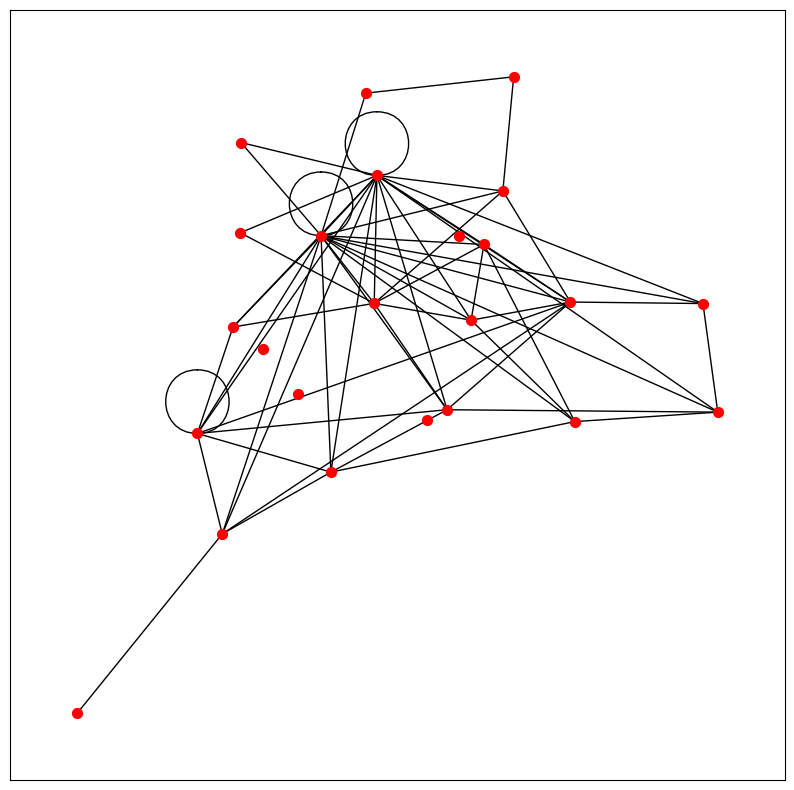

In [5]:
w_opt=4
x = [
0.60, 0.64, 0.36, -0.14, -0.61, -0.29, 0.21, 0.26, 0.27, 0.42, 0.33, 0.43, 0.27,
0.23, 0.12, 0.07, 0.06, 0.13, 0.49, 0.76, 0.81, 0.73, 0.66, 0.74, 0.66, 0.36, 0.45,
0.26, 0.30, 0.04, -0.23, -0.05, -0.04, -0.06, -0.59, -0.92, -0.91, -0.67, -0.71,
-0.32, -0.09, 0.00, 0.01, 0.31, 0.60, 0.70, 0.99, 1.14, 0.70, 0.13, -0.18, -0.32,
-0.47, -0.35, -0.59, -0.72, -1.11, -1.39, -1.54, -1.58, -1.68, -1.67, -1.21, -0.99,
-0.84, -0.68, -0.30, -0.13, -0.25, -0.35, -0.46, -0.86, -0.89, -0.79, -0.69, -0.35,
0.06, 0.31, 0.48, 0.56, 0.68, 0.89, 1.46, 1.74, 1.52, 1.25, 0.90, 0.38, -0.22, -0.69,
-1.07, -1.39, -1.60, -1.69, -1.64, -1.60, -1.54, -1.11, -0.93, -0.77, -0.52, -0.38,
-0.43, -0.65, -0.80, -1.05, -1.19, -1.06, -0.87, -0.67, -0.61, -0.50, -0.32, 0.02,
0.25, 0.47, 0.38, 0.26, 0.16, -0.25, -0.53, -0.52, -0.25, -0.25, -0.40, -0.42, -0.39,
-0.38, -0.18, -0.20, -0.14, -0.17, -0.49, -0.62, -0.28, 0.08, 0.32, 0.23, -0.06,
-0.03, 0.29, 0.44, 0.75, 0.71, 0.51, 0.42, 0.47, 0.70, 0.92, 1.18, 1.46, 1.93, 2.21,
2.36, 2.72, 2.66, 2.57, 2.26, 1.62, 0.91, 0.30, -0.03, -0.48, -0.58, -0.58, -0.74,
-0.76, -0.50, -0.43, -0.08, 0.03, 0.22, 0.37, 0.34, 0.25, -0.16, -0.43, -0.56, -0.97,
-0.98, -0.98, -0.78, -0.80, -0.51, -0.20, 0.04, 0.12, 0.09, 0.47, 0.90, 0.90, 0.89,
0.65, 0.71, 0.81, 0.62, 0.55, 0.45, 0.35, 0.04, 0.03, 0.48, 0.52, 0.52
]


nodos = crear_ind(x , w_opt)
print("len() de nodos es",len(nodos))

G, unique_nodes, nodo_a_sublista= crear_grafo(nodos, w_opt)
A = nx.to_numpy_array(G)
print(unique_nodes)
print("len() de unique_nodes es",len(unique_nodes))
# Dibujar el grafo
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G)  # Layout para la visualización
nx.draw_networkx_nodes(G, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G, pos, edge_color="black")
#nx.draw_networkx_labels(G, pos, {i: f"{i}" for i in G.nodes()}, font_size=8)
#MU,MUT,MC=calcular_entropia(unique_nodes,nodos)
#for i in range(len(MC)):
 #   print(MC[i])
#plt.title("Grafo")
def calcular_grado_medio(G):
    grados = [grado for _, grado in G.degree()]  # Obtener los grados de todos los nodos
    grado_medio = np.mean(grados)  # Calcular el grado medio
    return grado_medio
#G, unique_nodes = crear_grafo(nodos, w_opt)
grado_medio = calcular_grado_medio(G)

print(f"El grado medio de la red es: {grado_medio}")

if nx.is_connected(G):
    distancia_media=nx.average_shortest_path_length(G)
    print((f"La distancia minima promedio de la red es: {distancia_media}"))
    print("la distancia maxima es:",nx.diameter(G))
else:
    print("El grafo no está conectado. No se pueden calcular la distancia mínima promedio ni el diámetro.")
    print(f"Número de componentes conectados: {nx.number_connected_components(G)}")

print(A)
plt.show()

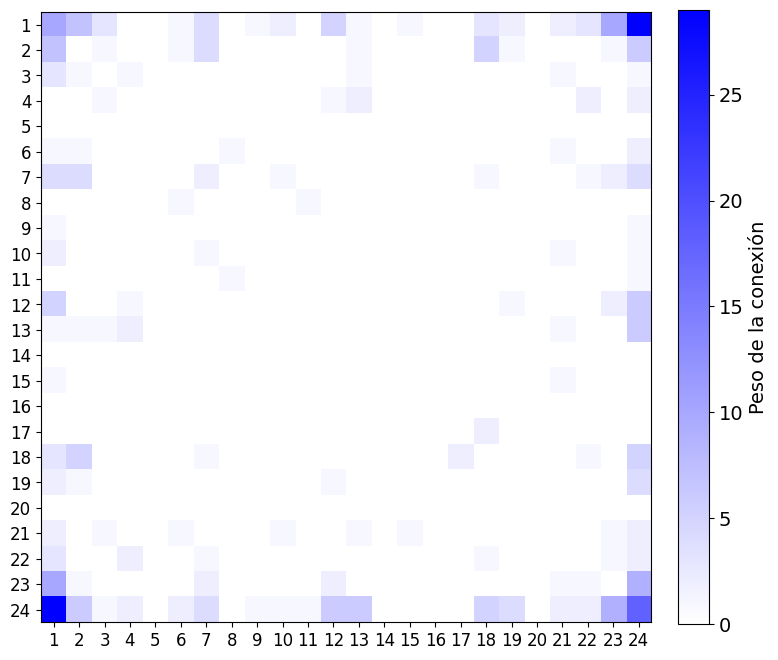

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

C = nx.adjacency_matrix(G).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})

fig, ax = plt.subplots(figsize=(8, 8))
azul_personalizado = LinearSegmentedColormap.from_list(
    'azul_personalizado',
    [(1, 1, 1), (0, 0, 1)]  # Blanco → Azul
)

im = ax.imshow(C, cmap=azul_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Peso de la conexión', fontsize=14)

plt.tight_layout()
plt.show()

In [7]:
from matplotlib.colors import ListedColormap

A = np.array(A, dtype=int)
#A1 = np.array(A1, dtype=int)
print("NIÑO 3.4")
print(A)

cmap = ListedColormap(['white', 'blue'])
#plt.imshow(A, cmap=cmap, interpolation='nearest')

#plt.imshow(A, cmap='gray_r', interpolation='nearest')

NIÑO 3.4
[[10  7  3  0  0  1  4  0  1  2  0  5  1  0  1  0  0  3  2  0  2  3 10 29]
 [ 7  0  1  0  0  1  4  0  0  0  0  0  1  0  0  0  0  5  1  0  0  0  1  6]
 [ 3  1  0  1  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  1  0  0  1]
 [ 0  0  1  0  0  0  0  0  0  0  0  1  2  0  0  0  0  0  0  0  0  2  0  2]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  1  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  2]
 [ 4  4  0  0  0  0  2  0  0  1  0  0  0  0  0  0  0  1  0  0  0  1  2  4]
 [ 0  0  0  0  0  1  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 2  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  1]
 [ 0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 5  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  2  6]
 [ 1  1  1  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  6]
 [ 0  0  0  0  0

In [8]:
nodos_activos = contar_nodos_activos(G)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 20 de 24 posibles
Porcentaje: 83.33%


In [9]:
nodos_existentes=obtener_nodos_que_aparecen(G)
print(nodos_existentes)

([0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16, 17, 18, 20, 21, 22, 23], [4, 13, 15, 19])


#Mapeo anomalias caudal Bolivar

len() de nodos es 201
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
len() de unique_nodes es 24
El grado medio de la red es: 9.333333333333334
El grafo no está conectado. No se pueden calcular la distancia mínima promedio ni el diámetro.
Número de componentes conectados: 2
[[ 1.  2.  0.  0.  0.  1.  4.  1.  0.  1.  0.  1.  0.  1.  0.  0.  1.  1.
   3.  4.  4.  2.  6. 11.]
 [ 2.  2.  1.  1.  2.  1.  1.  0.  0.  2.  0.  3.  0.  0.  1.  0.  0.  0.
   1.  0.  1.  2.  1.  1.]
 [ 0.  1.  0.  2.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  1.  0.  0.  1.
   0.  0.  0.  0.  0.  2.]
 [ 0.  1.  2.  0.  0.  2.  0.  0.  0.  2.  0. 

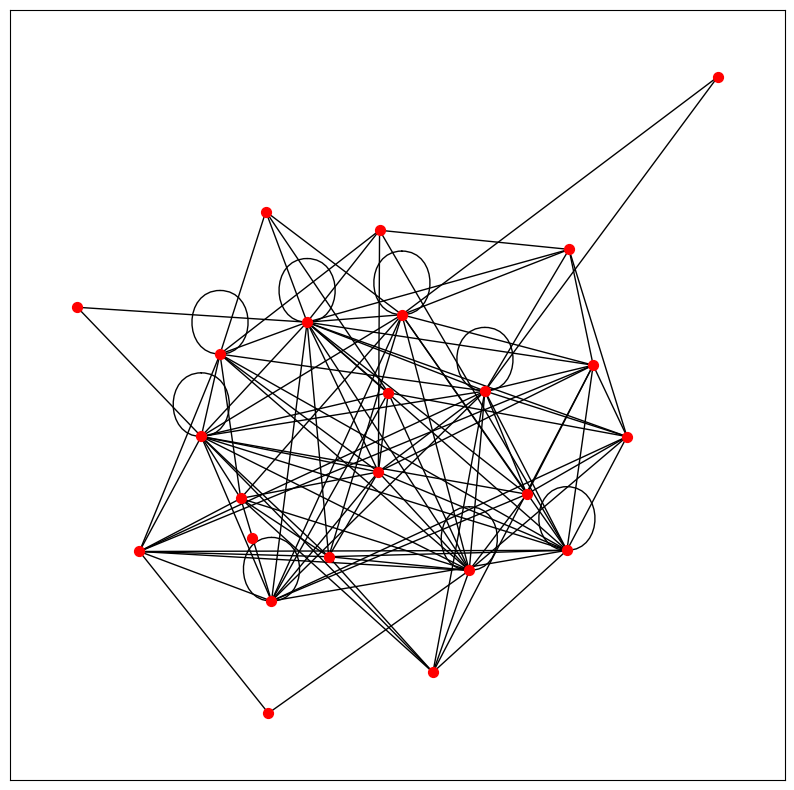

In [10]:
w_opt=4
x1 =  [
    -0.9613063168, -1.157069067, -1.386790481, -1.082572836, -0.3566588477,
    -0.03235249128, -0.3303903953, -0.0311025804, 0.4802647777, 1.010683803,
    1.999092312, 0.8282382911, 0.241654541, -0.6401360909, -0.6950316815,
    -0.8018833662, -0.08959279246, 0.9130188312, 0.6743444, 0.2169361203,
    0.4230544561, 1.054754997, 0.3121784033, 0.05587837495, 0.1108785632,
    0.3625993023, 0.2500591044, 0.3583909918, 0.8215825476, 0.2237592879,
    -0.7229034197, -1.340539789, -1.379640263, -1.327333796, -0.7562873894,
    0.3688427284, 0.1572118099, 2.343634487, 0.9462395457, 0.5120902253,
    -0.007065280103, -0.05251399241, 0.5199884324, 0.6457409911, 0.218037242,
    -0.3371499784, 0.1964859487, 0.5886806772, 0.08409728942, -0.4557310001,
    -1.022548987, 0.2111817951, -0.4007693785, -0.1953654509, 0.09182639044,
    -0.1400945447, 0.0928412732, 1.024837025, 0.987131064, -0.3155459656,
    0.5403128725, -0.04162939494, 0.4359435108, -0.8664878921, -1.362269903,
    -0.9076463719, -0.6603025737, -0.3650474997, -0.6394518296, -0.103970068,
    0.252553523, 1.373431599, 1.033046802, 1.322458673, 1.205888163,
    0.3757717172, -1.122614909, -2.229759315, -2.020212382, -1.891566497,
    -2.039800327, -1.952661296, -2.459289184, -2.134593588, -1.832082528,
    -1.506750987, -1.165761043, 0.2041925247, 0.8345474345, 0.8731396751,
    0.809549436, 0.4507706371, 0.3153406517, -0.1824068697, -0.3620418708,
    1.025380331, 0.7865587724, -0.00164575336, 1.266124255, 0.5685590925,
    1.160411447, 1.714768245, 0.9917129885, 0.2322228714, -0.616949399,
    -0.3530194323, 0.7601343194, 1.90431709, 2.093557572, 1.342929463,
    1.51166573, 3.137245398, 2.486834697, 1.266567398, 0.3294024336,
    0.5254813065, 0.5670887516, 0.3506629274, -0.3455477875, -1.080661773,
    -0.7978506129, -0.4813062258, 0.6828886814, 0.03891846774, 0.01153525545,
    0.1874727731, -0.9912596759, -1.383693624, -0.6423515511, 0.2226374965,
    -0.3561950875, -0.2279843184, -0.4077027113, -0.6228481136, -0.6207761776,
    -0.5634808318, -0.8802530673, -1.285702782, -1.152227489, -0.5325973285,
    -0.04845604035, 0.2532929476, 0.9092457563, -0.1730248311, -0.5037590204,
    0.3897000677, 0.1236387581, -0.3736518777, -1.195077385, -1.141055003,
    -0.8662246313, -0.6282511627, -0.09012227664, -1.559398383, -1.510904011,
    -0.8124968138, -0.6588344426, -1.090482859, -1.255439654, -0.7282186749,
    0.3713482613, 0.3687504197, 0.7291218292, 0.7725547181, 0.6258327695,
    0.5312086937, 0.06317313562, 0.5462159542, 1.588890107, 0.6763989881,
    1.126298615, 0.5941124568, 0.3023212154, 0.1511569477, 0.7636088195,
    1.048686038, -0.3356961397, -0.4347657844, 0.2747035998, -0.8541096211,
    -0.4602275602, -0.01974711607, -0.7447751488, -0.628122338, 0.4505271947,
    0.7100932177, 2.037933962, 2.272045621, 2.679456959, 1.948761548,
    0.1973414254, -0.7379924136, -1.014445137, -0.4203743724, -0.6576231904,
    -0.956044853, -1.02480649, -0.5643313897, -0.2039681242, 0.148454723,
    0.3905509452, -0.1461338322, -0.1617741575, -0.3545757207
]
nodos1 = crear_ind(x1 , w_opt)
print("len() de nodos es",len(nodos1))

G1, unique_nodes1, nodo_a_sublista1= crear_grafo(nodos1, w_opt)
A1 = nx.to_numpy_array(G1)
print(unique_nodes1)
print("len() de unique_nodes es",len(unique_nodes1))
# Dibujar el grafo
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G1)  # Layout para la visualización
nx.draw_networkx_nodes(G1, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G1, pos, edge_color="black")
#nx.draw_networkx_labels(G, pos, {i: f"{i}" for i in G.nodes()}, font_size=8)
#MU,MUT,MC=calcular_entropia(unique_nodes,nodos)
#for i in range(len(MC)):
 #   print(MC[i])
#plt.title("Grafo")
def calcular_grado_medio(G1):
    grados = [grado for _, grado in G1.degree()]  # Obtener los grados de todos los nodos
    grado_medio = np.mean(grados)  # Calcular el grado medio
    return grado_medio
#G, unique_nodes = crear_grafo(nodos, w_opt)
grado_medio = calcular_grado_medio(G1)
print(f"El grado medio de la red es: {grado_medio}")

if nx.is_connected(G1):
    distancia_media=nx.average_shortest_path_length(G1)
    print((f"La distancia minima promedio de la red es: {distancia_media}"))
    print("la distancia maxima es:",nx.diameter(G1))
else:
    print("El grafo no está conectado. No se pueden calcular la distancia mínima promedio ni el diámetro.")
    print(f"Número de componentes conectados: {nx.number_connected_components(G1)}")

print(A1)
plt.show()

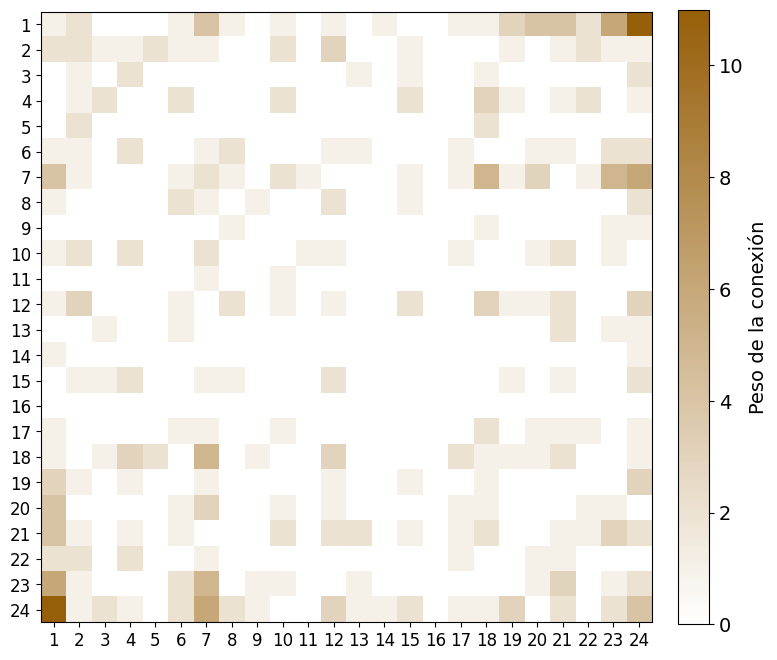

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap,to_rgb

C = nx.adjacency_matrix(G1).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})
fig, ax = plt.subplots(figsize=(8, 8))
# Blanco → Verde
color_hex = '#965f09'  # Cambia este valor por el hexadecimal que desees
verde_personalizado = LinearSegmentedColormap.from_list(
    'verde_personalizado',                # nombre del mapa
    [(1, 1, 1), to_rgb(color_hex)]        # blanco → color hexadecimal
)


im = ax.imshow(C, cmap=verde_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Peso de la conexión', fontsize=14)

plt.tight_layout()
plt.show()

In [12]:
print(unique_nodes)
print(nodo_a_sublista)
print(unique_nodes1)
print(nodo_a_sublista1)

{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
{0: (1, 2, 3, 4), 1: (1, 2, 4, 3), 2: (1, 3, 2, 4), 3: (1, 3, 4, 2), 4: (1, 4, 2, 3), 5: (1, 4, 3, 2), 6: (2, 1, 3, 4), 7: (2, 1, 4, 3), 8: (2, 3, 1, 4), 9: (2, 3, 4, 1), 10: (2, 4, 1, 3), 11: (2, 4, 3, 1), 12: (3, 1, 2, 4), 13: (3, 1, 4, 2), 14: (3, 2, 1, 4), 15: (3, 2, 4, 1), 16: (3, 4, 1, 2), 17: (3, 4, 2, 1), 18: (4, 1, 2, 3), 19: (4, 1, 3, 2), 20: (4, 2, 1, 3), 21: (4, 2, 3, 1), 22: (4, 3, 1, 2), 23: (4, 3, 2, 1)}
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, 

In [13]:
nodos_activos = contar_nodos_activos(G1)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 23 de 24 posibles
Porcentaje: 95.83%


In [14]:
nodos_existentes=obtener_nodos_que_aparecen(G1)
print(nodos_existentes)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 23], [15])


##W OPTIMO

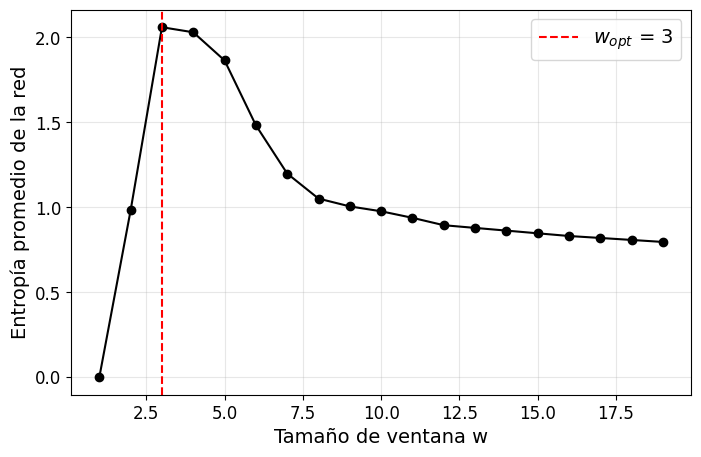

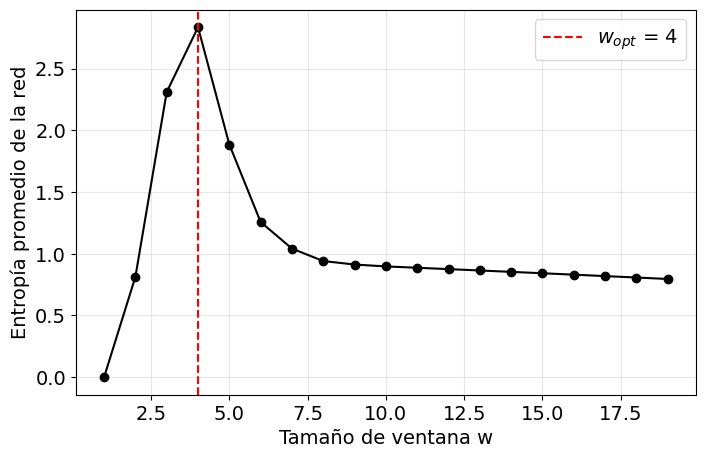

3
4


In [15]:
ventana=optimizar_w(x,1,20)
ventana1=optimizar_w(x1,1,20)
print(ventana)
print(ventana1)

##INTERSECCIÓN

NIÑO 3.4
[[10  7  3  0  0  1  4  0  1  2  0  5  1  0  1  0  0  3  2  0  2  3 10 29]
 [ 7  0  1  0  0  1  4  0  0  0  0  0  1  0  0  0  0  5  1  0  0  0  1  6]
 [ 3  1  0  1  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  1  0  0  1]
 [ 0  0  1  0  0  0  0  0  0  0  0  1  2  0  0  0  0  0  0  0  0  2  0  2]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  1  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  2]
 [ 4  4  0  0  0  0  2  0  0  1  0  0  0  0  0  0  0  1  0  0  0  1  2  4]
 [ 0  0  0  0  0  1  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 2  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  1]
 [ 0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 5  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  2  6]
 [ 1  1  1  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  6]
 [ 0  0  0  0  0

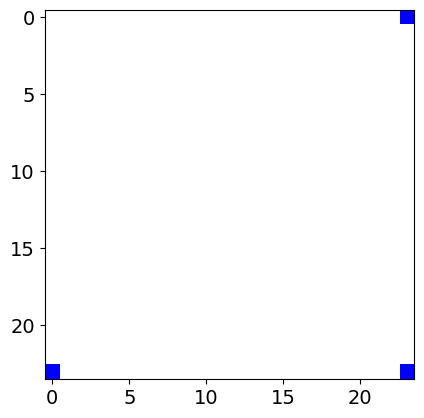

In [16]:
from matplotlib.colors import ListedColormap

A = np.array(A, dtype=int)
A1 = np.array(A1, dtype=int)
print("NIÑO 3.4")
print(A)
# contar diagonal (loops)
loops = np.count_nonzero(np.diag(A))

# contar fuera de la diagonal
off_diag = np.count_nonzero(A) - loops

# calcular M
M = off_diag / 2 + loops

print("M =", M)
cmap = ListedColormap(['white', 'blue'])
plt.imshow(A, cmap=cmap, interpolation='nearest')

#plt.imshow(A, cmap='gray_r', interpolation='nearest')



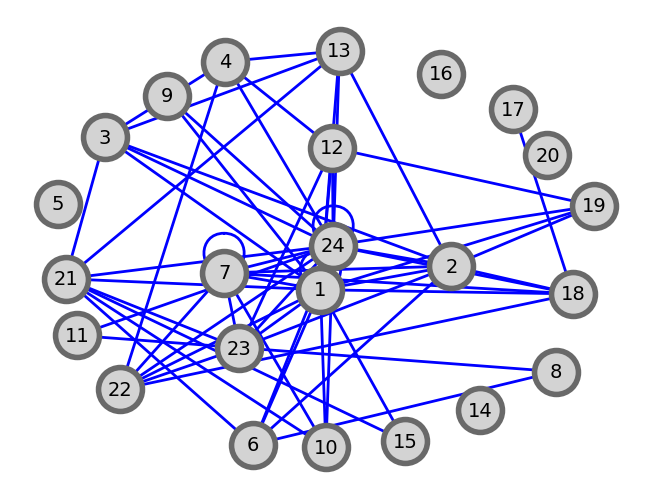

In [17]:
G = nx.from_numpy_array(A)
pos = nx.spring_layout(G, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in G.nodes()}

nx.draw(
    G, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='blue',
    width=2,
    font_size=14
)
plt.show()

CALAMAR
[[ 1  2  0  0  0  1  4  1  0  1  0  1  0  1  0  0  1  1  3  4  4  2  6 11]
 [ 2  2  1  1  2  1  1  0  0  2  0  3  0  0  1  0  0  0  1  0  1  2  1  1]
 [ 0  1  0  2  0  0  0  0  0  0  0  0  1  0  1  0  0  1  0  0  0  0  0  2]
 [ 0  1  2  0  0  2  0  0  0  2  0  0  0  0  2  0  0  3  1  0  1  2  0  1]
 [ 0  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0  0  0  0  0  0]
 [ 1  1  0  2  0  0  1  2  0  0  0  1  1  0  0  0  1  0  0  1  1  0  2  2]
 [ 4  1  0  0  0  1  2  1  0  2  1  0  0  0  1  0  1  5  1  3  0  1  5  6]
 [ 1  0  0  0  0  2  1  0  1  0  0  2  0  0  1  0  0  0  0  0  0  0  0  2]
 [ 0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  1  0  0  0  0  1  1]
 [ 1  2  0  2  0  0  2  0  0  0  1  1  0  0  0  0  1  0  0  1  2  0  1  0]
 [ 0  0  0  0  0  0  1  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  3  0  0  0  1  0  2  0  1  0  1  0  0  2  0  0  3  1  1  2  0  0  3]
 [ 0  0  1  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0  1  1]
 [ 1  0  0  0  0 

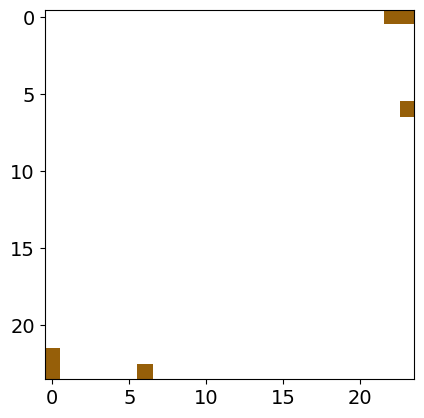

In [18]:
print("CALAMAR")
print(A1)
# contar diagonal (loops)
loops = np.count_nonzero(np.diag(A1))

# contar fuera de la diagonal
off_diag = np.count_nonzero(A1) - loops

# calcular M
M = off_diag / 2 + loops

print("M =", M)
cmap = ListedColormap(['white', '#965f09'])
plt.imshow(A1, cmap=cmap, interpolation='nearest')


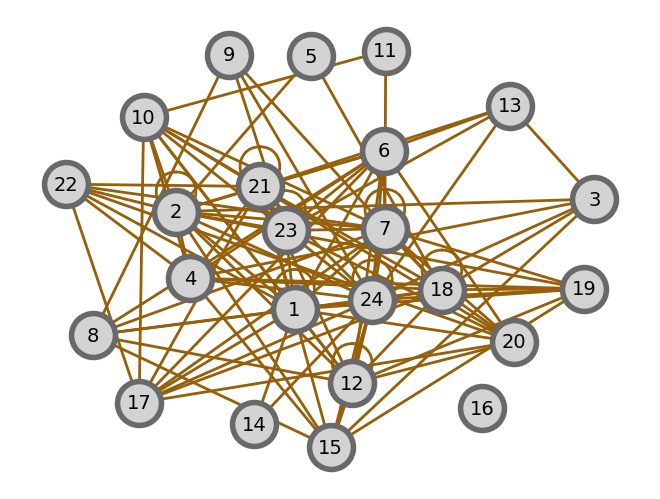

In [19]:
G1 = nx.from_numpy_array(A1)
pos = nx.spring_layout(G1, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in G1.nodes()}

nx.draw(
    G1, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='#965f09',
    width=2,
    font_size=14
)
plt.show()

In [20]:
print(A.shape, A1.shape)

(24, 24) (24, 24)


##INTERSECCIÓN


In [21]:
C = np.divide(A1 ,A, out=np.zeros_like(A, dtype=float), where=A!=0) * 100
C_clean = np.where(np.isinf(C), 0, C)
print(C_clean)

[[ 10.          28.57142857   0.           0.           0.
  100.         100.           0.           0.          50.
    0.          20.           0.           0.           0.
    0.           0.          33.33333333 150.           0.
  200.          66.66666667  60.          37.93103448]
 [ 28.57142857   0.         100.           0.           0.
  100.          25.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.         100.           0.
    0.           0.         100.          16.66666667]
 [  0.         100.           0.         200.           0.
    0.           0.           0.           0.           0.
    0.           0.         100.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.         200.        ]
 [  0.           0.         200.           0.           0.
    0.           0.           0.           0.           0.
    0.   

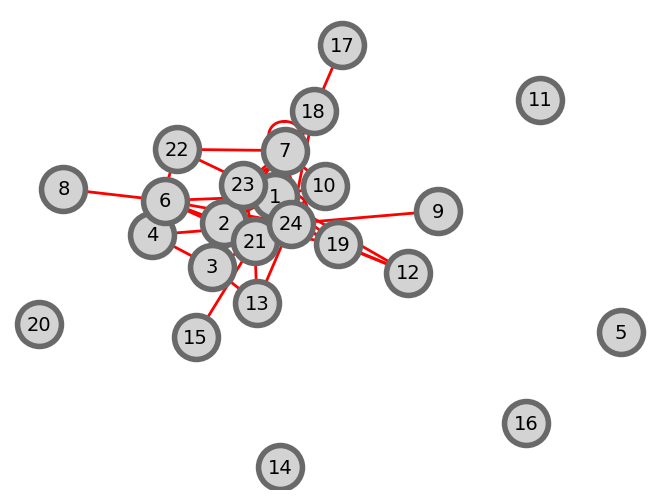

In [22]:
GC = nx.from_numpy_array(C_clean)
pos = nx.spring_layout(GC, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in GC.nodes()}

nx.draw(
    GC, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='red',
    width=2,
    font_size=14
)
plt.show()

INTERCEPCIÓN
M = 46.0


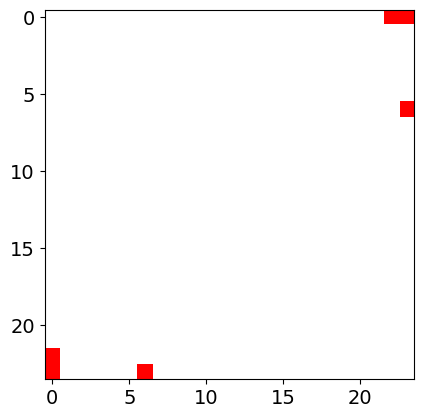

In [23]:
print("INTERCEPCIÓN")
#print(C_clean)
# contar diagonal (loops)
loops = np.count_nonzero(np.diag(C_clean))

# contar fuera de la diagonal
off_diag = np.count_nonzero(C_clean) - loops

# calcular M
M = off_diag / 2 + loops

print("M =", M)
cmap = ListedColormap(['white', 'red'])
plt.imshow(A1, cmap=cmap, interpolation='nearest')

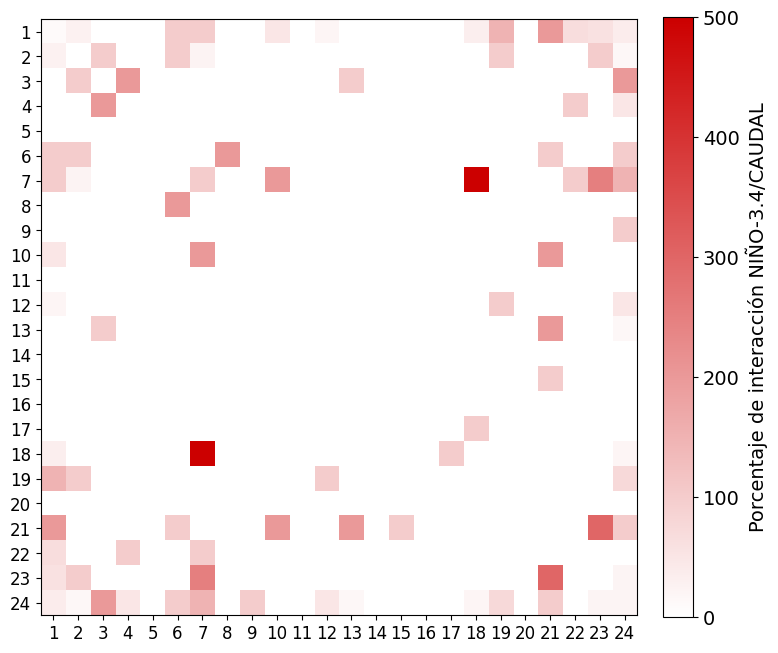

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

C = nx.adjacency_matrix(GC).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})

fig, ax = plt.subplots(figsize=(8, 8))
# Blanco → Rojo
rojo_personalizado = LinearSegmentedColormap.from_list(
    'rojo_personalizado',
    [(1, 1, 1), (0.8, 0, 0)]  # Blanco → Rojo
)

im = ax.imshow(C, cmap=rojo_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Porcentaje de interacción NIÑO-3.4/CAUDAL', fontsize=14)

plt.tight_layout()
plt.show()

In [25]:
nodos_activos = contar_nodos_activos(GC)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 19 de 24 posibles
Porcentaje: 79.17%


In [26]:
nodos_existentes=obtener_nodos_que_aparecen(GC)
print(nodos_existentes)

([0, 1, 2, 3, 5, 6, 7, 8, 9, 11, 12, 14, 16, 17, 18, 20, 21, 22, 23], [4, 10, 13, 15, 19])


In [27]:
upper = np.triu(C_clean)
promedio = np.mean(upper)
print("La influencia del NIÑO 3.4 en el caudal es:",promedio,"%")

La influencia del NIÑO 3.4 en el caudal es: 8.774792084777719 %


#PORCENTAJE DE INTERACCIÓN

In [28]:
import numpy as np

# Suponiendo que ya tienes las matrices A y A1 (24x24)
# y has calculado C_clean como:
C = np.divide(A1, A, out=np.zeros_like(A, dtype=float), where=A!=0) * 100
C_clean = np.where(np.isinf(C), 0, C)

# Nodos a ignorar (que no aparecen en A pero sí en A1)
nodos_ignorar = [4, 13, 19]  # Basado en tu análisis

# Función para calcular promedio ignorando ciertos nodos
def promedio_sin_nodos(matriz, nodos_ignorar):
    """
    Calcula el promedio de la parte triangular superior de la matriz,
    excluyendo las entradas que involucren los nodos especificados.
    """
    n = matriz.shape[0]  # 24

    # Crear máscara de nodos válidos (True para nodos que SÍ se consideran)
    nodos_validos = np.ones(n, dtype=bool)
    nodos_validos[nodos_ignorar] = False

    # Máscara triangular superior (incluyendo diagonal)
    triu_mask = np.triu(np.ones((n, n), dtype=bool))

    # Máscara combinada: triangular superior y que ambos nodos sean válidos
    mask = triu_mask & nodos_validos[None, :] & nodos_validos[:, None]

    # Calcular el promedio solo sobre las entradas seleccionadas
    return matriz[mask].mean()

# Calcular el promedio corregido
promedio_corregido = promedio_sin_nodos(C_clean, nodos_ignorar)
print("La influencia del NIÑO 3.4 en el caudal (corregida) es:", promedio_corregido, "%")

# También puedes calcular el promedio original para comparación
upper_original = np.triu(C_clean)
promedio_original = np.mean(upper_original)
print("Promedio original (con nodos inactivos):", promedio_original, "%")
print("Diferencia:", promedio_corregido - promedio_original, "%")

La influencia del NIÑO 3.4 en el caudal (corregida) es: 21.88000104256262 %
Promedio original (con nodos inactivos): 8.774792084777719 %
Diferencia: 13.1052089577849 %


##MÉTRICAS

In [29]:
import networkx as nx
import numpy as np

# Intento de importar correctamente python-louvain
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def calcular_metricas_red(G, nombre_grafo):
    """
    Calcula e imprime métricas de red considerando solo nodos activos.
    Las etiquetas en pantalla se muestran como 1‑based.
    """
    print(f"\n=== Métricas para {nombre_grafo} ===")

    # Identificar nodos activos (grado > 0)
    nodos_activos = [n for n in G.nodes() if G.degree(n) > 0]
    num_activos = len(nodos_activos)
    print(f"Nodos activos: {num_activos} de {G.number_of_nodes()}")

    if num_activos == 0:
        print("No hay nodos activos. No se pueden calcular métricas.")
        return

    # Subgrafo inducido por los nodos activos
    G_activo = G.subgraph(nodos_activos).copy()

    # ---- Grado medio (solo activos) ----
    grados = [d for n, d in G_activo.degree()]
    grado_medio = np.mean(grados)
    print(f"Grado medio (solo activos): {grado_medio:.4f}")

    # ---- Coeficiente de clustering promedio (solo activos) ----
    clustering = nx.average_clustering(G, nodes=nodos_activos)
    print(f"Coeficiente de clustering promedio (solo activos): {clustering:.4f}")

    # ---- Diámetro y distancia promedio ----
    if nx.is_connected(G_activo):
        diametro = nx.diameter(G_activo)
        dist_prom = nx.average_shortest_path_length(G_activo)
        print(f"Diámetro (componente activa): {diametro}")
        print(f"Distancia promedio (componente activa): {dist_prom:.4f}")
    else:
        componentes = list(nx.connected_components(G_activo))
        comp_gigante = max(componentes, key=len)
        G_gigante = G_activo.subgraph(comp_gigante)
        diametro = nx.diameter(G_gigante)
        dist_prom = nx.average_shortest_path_length(G_gigante)
        print(f"El grafo activo no es conexo. Métricas sobre la componente gigante ({len(comp_gigante)} nodos):")
        print(f"  Diámetro: {diametro}")
        print(f"  Distancia promedio: {dist_prom:.4f}")

    # ---- Modularidad (sobre grafo activo) ----
    # (Requiere python-louvain instalado)
    particion = community_louvain.best_partition(G_activo)
    modularidad = community_louvain.modularity(particion, G_activo)
    print(f"Modularidad (sobre grafo activo): {modularidad:.4f}")

    # ---- Centralidades ----
    # Centralidad de grado (solo activos)
    cent_grado = nx.degree_centrality(G_activo)
    prom_cent_grado = np.mean(list(cent_grado.values()))
    print(f"Centralidad de grado promedio (activos): {prom_cent_grado:.4f}")

    # Top 3 nodos con mayor centralidad de grado (etiquetas 1‑based)
    top_nodos = sorted(cent_grado.items(), key=lambda x: x[1], reverse=True)[:3]
    print("Top 3 nodos activos con mayor centralidad de grado:")
    for nodo, valor in top_nodos:
        print(f"  Nodo {nodo+1}: {valor:.4f}")

    # Centralidad de cercanía (sobre la componente usada)
    if nx.is_connected(G_activo):
        cent_cercania = nx.closeness_centrality(G_activo)
    else:
        cent_cercania = nx.closeness_centrality(G_gigante)
    prom_cent_cercania = np.mean(list(cent_cercania.values()))
    print(f"Centralidad de cercanía promedio (componente usada): {prom_cent_cercania:.4f}")

    # Centralidad de intermediación (betweenness) sobre todo el grafo activo
    cent_inter = nx.betweenness_centrality(G_activo)
    prom_cent_inter = np.mean(list(cent_inter.values()))
    print(f"Centralidad de intermediación promedio (activos): {prom_cent_inter:.4f}")

In [30]:
calcular_metricas_red(G, "NIÑO 3.4")
calcular_metricas_red(G1, "BOLIVAR")
calcular_metricas_red(GC, "INTERSECCIÓN")


=== Métricas para NIÑO 3.4 ===
Nodos activos: 20 de 24
Grado medio (solo activos): 6.2000
Coeficiente de clustering promedio (solo activos): 0.5474
Diámetro (componente activa): 4
Distancia promedio (componente activa): 1.8368
Modularidad (sobre grafo activo): 0.1393
Centralidad de grado promedio (activos): 0.3263
Top 3 nodos activos con mayor centralidad de grado:
  Nodo 24: 0.9474
  Nodo 1: 0.8947
  Nodo 2: 0.4737
Centralidad de cercanía promedio (componente usada): 0.5655
Centralidad de intermediación promedio (activos): 0.0465

=== Métricas para BOLIVAR ===
Nodos activos: 23 de 24
Grado medio (solo activos): 9.7391
Coeficiente de clustering promedio (solo activos): 0.5795
Diámetro (componente activa): 3
Distancia promedio (componente activa): 1.6245
Modularidad (sobre grafo activo): 0.1732
Centralidad de grado promedio (activos): 0.4427
Top 3 nodos activos con mayor centralidad de grado:
  Nodo 24: 0.8636
  Nodo 1: 0.7727
  Nodo 2: 0.7273
Centralidad de cercanía promedio (componen

##MÉTRICAS PESADAS

In [31]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def calcular_metricas_red_pesada(G, nombre_grafo, usar_inverso_para_distancias=True):
    """
    Calcula e imprime métricas de red considerando pesos en las aristas.

    Parámetros:
    - G: grafo de NetworkX con aristas que tienen atributo 'weight' 
    - nombre_grafo: título para la salida
    - usar_inverso_para_distancias: si True, usa 1/weight como distancia para caminos;
      si False, ignora los pesos para distancias (trata como no pesado).
    """
    print(f"\n=== Métricas PESADAS para {nombre_grafo} ===")

    # Nodos activos (grado no pesado > 0, pero usaremos fuerza > 0 para activos pesados)
    # Consideramos nodos activos aquellos con fuerza > 0
    fuerzas = dict(G.degree(weight='weight'))
    nodos_activos = [n for n, f in fuerzas.items() if f > 0]
    num_activos = len(nodos_activos)
    print(f"Nodos con fuerza > 0: {num_activos} de {G.number_of_nodes()}")

    if num_activos == 0:
        print("No hay nodos con fuerza positiva. No se pueden calcular métricas.")
        return

    # ---- Grado medio pesado (fuerza promedio) ----
    fuerza_promedio = np.mean(list(fuerzas.values()))
    print(f"Fuerza promedio (grado pesado): {fuerza_promedio:.4f}")

    # ---- Coeficiente de clustering pesado ----
    # Utiliza la definición estándar de clustering pesado de NetworkX
    clustering_pesado = nx.average_clustering(G, weight='weight')
    print(f"Coeficiente de clustering pesado promedio: {clustering_pesado:.4f}")

    # ---- Preparar grafo con distancias (inverso del peso) si se requiere ----
    if usar_inverso_para_distancias:
        # Crear una copia del grafo con atributo 'distance' = 1/weight
        G_dist = nx.Graph()
        for u, v, data in G.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
    else:
        G_dist = G  # usa el grafo original sin considerar pesos para distancias

    # ---- Diámetro y distancia promedio pesados ----
    # Se calculan sobre el subgrafo de nodos activos (para evitar aislados)
    G_activo = G.subgraph(nodos_activos).copy()
    if usar_inverso_para_distancias:
        G_dist_activo = G_dist.subgraph(nodos_activos).copy()
    else:
        G_dist_activo = G_activo

    if nx.is_connected(G_dist_activo):
        diametro = nx.diameter(G_dist_activo, weight='distance' if usar_inverso_para_distancias else None)
        dist_prom = nx.average_shortest_path_length(G_dist_activo, weight='distance' if usar_inverso_para_distancias else None)
        print(f"Diámetro (pesado): {diametro}")
        print(f"Distancia promedio (pesada): {dist_prom:.4f}")
    else:
        componentes = list(nx.connected_components(G_dist_activo))
        comp_gigante = max(componentes, key=len)
        G_gigante = G_dist_activo.subgraph(comp_gigante)
        diametro = nx.diameter(G_gigante, weight='distance' if usar_inverso_para_distancias else None)
        dist_prom = nx.average_shortest_path_length(G_gigante, weight='distance' if usar_inverso_para_distancias else None)
        print(f"El grafo activo no es conexo. Métricas sobre la componente gigante ({len(comp_gigante)} nodos):")
        print(f"  Diámetro (pesado): {diametro}")
        print(f"  Distancia promedio (pesada): {dist_prom:.4f}")

    # ---- Modularidad pesada ----
    # La partición de Louvain puede usar pesos
    particion = community_louvain.best_partition(G, weight='weight')
    modularidad = community_louvain.modularity(particion, G, weight='weight')
    print(f"Modularidad (pesada): {modularidad:.4f}")

    # ---- Centralidades pesadas ----
    # Centralidad de grado pesada (fuerza normalizada)
    # Normalizamos por la suma total de fuerzas de la red (o por el máximo posible)
    total_fuerza = sum(fuerzas.values())
    cent_fuerza = {n: f / total_fuerza for n, f in fuerzas.items()}
    prom_cent_fuerza = np.mean(list(cent_fuerza.values()))
    print(f"Centralidad de fuerza promedio: {prom_cent_fuerza:.6f}")

    # Top 3 nodos con mayor fuerza (etiquetas 1‑based)
    top_nodos = sorted(fuerzas.items(), key=lambda x: x[1], reverse=True)[:3]
    print("Top 3 nodos con mayor fuerza:")
    for nodo, valor in top_nodos:
        print(f"  Nodo {nodo+1}: {valor:.2f}")

    # Centralidad de cercanía pesada (usando distancias inversas)
    if usar_inverso_para_distancias:
        # Usar el grafo con distancias (G_dist)
        cent_cercania = nx.closeness_centrality(G_dist, distance='distance')
        prom_cent_cercania = np.mean(list(cent_cercania.values()))
        print(f"Centralidad de cercanía promedio (pesada, con inverso): {prom_cent_cercania:.6f}")
    else:
        # Versión no pesada (longitudes de camino = 1 por arista)
        cent_cercania = nx.closeness_centrality(G)
        prom_cent_cercania = np.mean(list(cent_cercania.values()))
        print(f"Centralidad de cercanía promedio (no pesada): {prom_cent_cercania:.6f}")

    # Centralidad de intermediación pesada (usando distancias inversas)
    if usar_inverso_para_distancias:
        cent_inter = nx.betweenness_centrality(G_dist, weight='distance')
    else:
        cent_inter = nx.betweenness_centrality(G, weight=None)
    prom_cent_inter = np.mean(list(cent_inter.values()))
    print(f"Centralidad de intermediación promedio: {prom_cent_inter:.6f}")
    

In [32]:
# Para NIÑO 3.4 (G)
calcular_metricas_red_pesada(G, "NIÑO 3.4")


# Para CAUDAL (G1)
calcular_metricas_red_pesada(G1, "BOLIVAR")


# Para INTERSECCIÓN (GC, si existe)
calcular_metricas_red_pesada(GC, "INTERSECCIÓN")



=== Métricas PESADAS para NIÑO 3.4 ===
Nodos con fuerza > 0: 20 de 24
Fuerza promedio (grado pesado): 16.4167
Coeficiente de clustering pesado promedio: 0.0432
Diámetro (pesado): 2.5344827586206895
Distancia promedio (pesada): 0.9020
Modularidad (pesada): 0.1393
Centralidad de fuerza promedio: 0.041667
Top 3 nodos con mayor fuerza:
  Nodo 24: 117.00
  Nodo 1: 94.00
  Nodo 2: 27.00
Centralidad de cercanía promedio (pesada, con inverso): 1.258012
Centralidad de intermediación promedio: 0.064474

=== Métricas PESADAS para BOLIVAR ===
Nodos con fuerza > 0: 23 de 24
Fuerza promedio (grado pesado): 16.4167
Coeficiente de clustering pesado promedio: 0.0825
Diámetro (pesado): 2.166666666666667
Distancia promedio (pesada): 0.9337
Modularidad (pesada): 0.1714
Centralidad de fuerza promedio: 0.041667
Top 3 nodos con mayor fuerza:
  Nodo 24: 50.00
  Nodo 1: 45.00
  Nodo 7: 37.00
Centralidad de cercanía promedio (pesada, con inverso): 1.155236
Centralidad de intermediación promedio: 0.051258

=== 

In [33]:
import networkx as nx
import numpy as np
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def metricas_formateadas(G_nino, G_caudal, G_interseccion=None, decimales=2):
    """
    Calcula las métricas no pesadas y pesadas para los tres grafos.
    Retorna un diccionario con las siguientes claves:
        'grado_medio', 'clustering', 'diametro', 'distancia_promedio',
        'modularidad', 'cent_grado_prom', 'cent_cercania_prom', 'cent_inter_prom'
    Cada valor es una cadena con el formato:
        "(a,b),(c,d),(e,f)" donde a,b son los valores del primer grafo, etc.
    Si un valor es None, se escribe como "None".
    """
    # ------------------------------------------------------------------------
    # Función auxiliar para métricas no pesadas de un grafo
    # ------------------------------------------------------------------------
    def _no_pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        grados = [d for n, d in G.degree()]
        grado_medio = float(np.mean(grados))
        clustering = float(nx.average_clustering(G))
        if nx.is_connected(G):
            diametro = float(nx.diameter(G))
            dist_prom = float(nx.average_shortest_path_length(G))
        else:
            comps = list(nx.connected_components(G))
            if comps:
                G_gig = G.subgraph(max(comps, key=len)).copy()
                diametro = float(nx.diameter(G_gig))
                dist_prom = float(nx.average_shortest_path_length(G_gig))
            else:
                diametro = dist_prom = None
        try:
            particion = community_louvain.best_partition(G)
            modularidad = float(community_louvain.modularity(particion, G))
        except:
            modularidad = None
        cent_grado = nx.degree_centrality(G)
        prom_cent_grado = float(np.mean(list(cent_grado.values())))
        if nx.is_connected(G):
            cent_cercania = nx.closeness_centrality(G)
            prom_cent_cercania = float(np.mean(list(cent_cercania.values())))
        else:
            prom_cent_cercania = None
        cent_inter = nx.betweenness_centrality(G)
        prom_cent_inter = float(np.mean(list(cent_inter.values())))
        return {
            'grado_medio': grado_medio,
            'clustering': clustering,
            'diametro': diametro,
            'distancia_promedio': dist_prom,
            'modularidad': modularidad,
            'cent_grado_prom': prom_cent_grado,
            'cent_cercania_prom': prom_cent_cercania,
            'cent_inter_prom': prom_cent_inter
        }

    # ------------------------------------------------------------------------
    # Función auxiliar para métricas pesadas de un grafo
    # ------------------------------------------------------------------------
    def _pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        fuerzas = dict(G.degree(weight='weight'))
        fuerza_media = float(np.mean(list(fuerzas.values())))
        clustering_pesado = float(nx.average_clustering(G, weight='weight'))
        G_dist = nx.Graph()
        for u, v, data in G.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
        nodos_activos = [n for n, f in fuerzas.items() if f > 0]
        if not nodos_activos:
            diam_pesado = dist_prom_pesado = None
        else:
            G_activo = G.subgraph(nodos_activos).copy()
            G_dist_activo = G_dist.subgraph(nodos_activos).copy()
            if nx.is_connected(G_dist_activo):
                diam_pesado = float(nx.diameter(G_dist_activo, weight='distance'))
                dist_prom_pesado = float(nx.average_shortest_path_length(G_dist_activo, weight='distance'))
            else:
                comps = list(nx.connected_components(G_dist_activo))
                if comps:
                    G_gig = G_dist_activo.subgraph(max(comps, key=len)).copy()
                    diam_pesado = float(nx.diameter(G_gig, weight='distance'))
                    dist_prom_pesado = float(nx.average_shortest_path_length(G_gig, weight='distance'))
                else:
                    diam_pesado = dist_prom_pesado = None
        try:
            particion_pesada = community_louvain.best_partition(G, weight='weight')
            modularidad_pesada = float(community_louvain.modularity(particion_pesada, G, weight='weight'))
        except:
            modularidad_pesada = None
        total_fuerza = sum(fuerzas.values())
        if total_fuerza > 0:
            cent_fuerza_prom = float(np.mean([f/total_fuerza for f in fuerzas.values()]))
        else:
            cent_fuerza_prom = 0.0
        if nodos_activos:
            cent_cercania_pesada = nx.closeness_centrality(G_dist, distance='distance')
            prom_cent_cercania_pesada = float(np.mean(list(cent_cercania_pesada.values())))
        else:
            prom_cent_cercania_pesada = None
        cent_inter_pesada = nx.betweenness_centrality(G_dist, weight='distance')
        prom_cent_inter_pesada = float(np.mean(list(cent_inter_pesada.values())))
        return {
            'grado_medio': fuerza_media,
            'clustering': clustering_pesado,
            'diametro': diam_pesado,
            'distancia_promedio': dist_prom_pesado,
            'modularidad': modularidad_pesada,
            'cent_grado_prom': cent_fuerza_prom,
            'cent_cercania_prom': prom_cent_cercania_pesada,
            'cent_inter_prom': prom_cent_inter_pesada
        }

    grafos = [G_nino, G_caudal, G_interseccion]
    no_pesadas = [_no_pesadas(g) for g in grafos]
    pesadas = [_pesadas(g) for g in grafos]

    metricas = [
        'grado_medio',
        'clustering',
        'diametro',
        'distancia_promedio',
        'modularidad',
        'cent_grado_prom',
        'cent_cercania_prom',
        'cent_inter_prom'
    ]

    resultado = {}
    for met in metricas:
        pares = []
        for i in range(3):
            val_no = no_pesadas[i][met] if no_pesadas[i] is not None else None
            val_pes = pesadas[i][met] if pesadas[i] is not None else None
            # Formatear los números con la precisión indicada
            if val_no is None:
                str_no = "None"
            else:
                str_no = f"{val_no:.{decimales}f}"
            if val_pes is None:
                str_pes = "None"
            else:
                str_pes = f"{val_pes:.{decimales}f}"
            pares.append(f"({str_no},{str_pes})")
        # Unir los tres pares con comas
        resultado[met] = ",".join(pares)

    return resultado

In [34]:
res = metricas_formateadas(G, G1, GC, decimales=2)

# Ahora puedes acceder a cada métrica como cadena
print("grado =", res['grado_medio'])
print("clustering =", res['clustering'])
print("diametro =", res['diametro'])
print("distancia_promedio =", res['distancia_promedio'])
print("modularidad =", res['modularidad'])
print("cent_grado_prom =", res['cent_grado_prom'])
print("cent_cercania_prom =", res['cent_cercania_prom'])
print("cent_inter_prom =", res['cent_inter_prom'])

grado = (5.17,16.42),(9.33,16.42),(3.83,421.19)
clustering = (0.46,0.04),(0.56,0.08),(0.34,0.05)
diametro = (4.00,2.53),(3.00,2.17),(4.00,0.04)
distancia_promedio = (1.84,0.90),(1.62,0.93),(1.99,0.02)
modularidad = (0.14,0.14),(0.17,0.17),(0.34,0.34)
cent_grado_prom = (0.22,0.04),(0.41,0.04),(0.17,0.04)
cent_cercania_prom = (None,1.26),(None,1.16),(None,60.71)
cent_inter_prom = (0.03,0.06),(0.03,0.05),(0.03,0.09)


##Para nodos disponibles

In [35]:
import networkx as nx
import numpy as np
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def metricas_formateadas(G_nino, G_caudal, G_interseccion=None, decimales=2):
    """
    Calcula las métricas no pesadas y pesadas para los tres grafos,
    considerando únicamente los nodos activos (grado > 0 o fuerza > 0).
    Retorna un diccionario con las siguientes claves:
        'grado_medio', 'clustering', 'diametro', 'distancia_promedio',
        'modularidad', 'cent_grado_prom', 'cent_cercania_prom', 'cent_inter_prom'
    Cada valor es una cadena con el formato:
        "(a,b),(c,d),(e,f)" donde a,b son los valores del primer grafo, etc.
    Si un valor es None, se escribe como "None".
    """
    # ------------------------------------------------------------------------
    # Función auxiliar para métricas no pesadas (solo nodos activos)
    # ------------------------------------------------------------------------
    def _no_pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        # Nodos activos: grado no ponderado > 0
        nodos_activos = [n for n, d in G.degree() if d > 0]
        if not nodos_activos:
            return None
        G_activo = G.subgraph(nodos_activos).copy()
        grados = [d for n, d in G_activo.degree()]
        grado_medio = float(np.mean(grados))
        clustering = float(nx.average_clustering(G_activo))
        # Diámetro y distancia promedio sobre la componente conexa más grande
        if nx.is_connected(G_activo):
            diametro = float(nx.diameter(G_activo))
            dist_prom = float(nx.average_shortest_path_length(G_activo))
        else:
            comps = list(nx.connected_components(G_activo))
            if comps:
                G_gig = G_activo.subgraph(max(comps, key=len)).copy()
                diametro = float(nx.diameter(G_gig))
                dist_prom = float(nx.average_shortest_path_length(G_gig))
            else:
                diametro = dist_prom = None
        try:
            particion = community_louvain.best_partition(G_activo)
            modularidad = float(community_louvain.modularity(particion, G_activo))
        except:
            modularidad = None
        cent_grado = nx.degree_centrality(G_activo)
        prom_cent_grado = float(np.mean(list(cent_grado.values())))
        # Centralidad de cercanía sobre la componente usada
        if nx.is_connected(G_activo):
            cent_cercania = nx.closeness_centrality(G_activo)
            prom_cent_cercania = float(np.mean(list(cent_cercania.values())))
        else:
            if comps:
                G_gig = G_activo.subgraph(max(comps, key=len)).copy()
                cent_cercania = nx.closeness_centrality(G_gig)
                prom_cent_cercania = float(np.mean(list(cent_cercania.values())))
            else:
                prom_cent_cercania = None
        cent_inter = nx.betweenness_centrality(G_activo)
        prom_cent_inter = float(np.mean(list(cent_inter.values())))
        return {
            'grado_medio': grado_medio,
            'clustering': clustering,
            'diametro': diametro,
            'distancia_promedio': dist_prom,
            'modularidad': modularidad,
            'cent_grado_prom': prom_cent_grado,
            'cent_cercania_prom': prom_cent_cercania,
            'cent_inter_prom': prom_cent_inter
        }

    # ------------------------------------------------------------------------
    # Función auxiliar para métricas pesadas (solo nodos con fuerza > 0)
    # ------------------------------------------------------------------------
    def _pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        # Fuerzas (grados ponderados)
        fuerzas = dict(G.degree(weight='weight'))
        nodos_activos = [n for n, f in fuerzas.items() if f > 0]
        if not nodos_activos:
            return None
        G_activo = G.subgraph(nodos_activos).copy()
        # Fuerza media sobre nodos activos
        fuerza_media = float(np.mean([fuerzas[n] for n in nodos_activos]))
        clustering_pesado = float(nx.average_clustering(G_activo, weight='weight'))
        # Construir grafo de distancias (inverso del peso)
        G_dist = nx.Graph()
        for u, v, data in G_activo.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
        # Diámetro y distancia promedio pesados sobre la componente conexa más grande
        if nx.is_connected(G_dist):
            diam_pesado = float(nx.diameter(G_dist, weight='distance'))
            dist_prom_pesado = float(nx.average_shortest_path_length(G_dist, weight='distance'))
        else:
            comps = list(nx.connected_components(G_dist))
            if comps:
                G_gig = G_dist.subgraph(max(comps, key=len)).copy()
                diam_pesado = float(nx.diameter(G_gig, weight='distance'))
                dist_prom_pesado = float(nx.average_shortest_path_length(G_gig, weight='distance'))
            else:
                diam_pesado = dist_prom_pesado = None
        try:
            particion_pesada = community_louvain.best_partition(G_activo, weight='weight')
            modularidad_pesada = float(community_louvain.modularity(particion_pesada, G_activo, weight='weight'))
        except:
            modularidad_pesada = None
        total_fuerza = sum(fuerzas[n] for n in nodos_activos)
        if total_fuerza > 0:
            cent_fuerza_prom = float(np.mean([fuerzas[n]/total_fuerza for n in nodos_activos]))
        else:
            cent_fuerza_prom = 0.0
        # Centralidad de cercanía pesada sobre el grafo de distancias (solo activos)
        if nodos_activos:
            # Asegurar que trabajamos sobre el subgrafo de distancias con nodos activos
            G_dist_activo = G_dist.subgraph(nodos_activos).copy()
            if G_dist_activo.number_of_nodes() > 0:
                cent_cercania_pesada = nx.closeness_centrality(G_dist_activo, distance='distance')
                prom_cent_cercania_pesada = float(np.mean(list(cent_cercania_pesada.values())))
            else:
                prom_cent_cercania_pesada = None
        else:
            prom_cent_cercania_pesada = None
        # Centralidad de intermediación pesada (sobre el grafo de distancias, activos)
        cent_inter_pesada = nx.betweenness_centrality(G_dist_activo, weight='distance')
        prom_cent_inter_pesada = float(np.mean(list(cent_inter_pesada.values())))
        return {
            'grado_medio': fuerza_media,
            'clustering': clustering_pesado,
            'diametro': diam_pesado,
            'distancia_promedio': dist_prom_pesado,
            'modularidad': modularidad_pesada,
            'cent_grado_prom': cent_fuerza_prom,
            'cent_cercania_prom': prom_cent_cercania_pesada,
            'cent_inter_prom': prom_cent_inter_pesada
        }

    grafos = [G_nino, G_caudal, G_interseccion]
    no_pesadas = [_no_pesadas(g) for g in grafos]
    pesadas = [_pesadas(g) for g in grafos]

    metricas = [
        'grado_medio',
        'clustering',
        'diametro',
        'distancia_promedio',
        'modularidad',
        'cent_grado_prom',
        'cent_cercania_prom',
        'cent_inter_prom'
    ]

    resultado = {}
    for met in metricas:
        pares = []
        for i in range(3):
            val_no = no_pesadas[i][met] if no_pesadas[i] is not None else None
            val_pes = pesadas[i][met] if pesadas[i] is not None else None
            if val_no is None:
                str_no = "None"
            else:
                str_no = f"{val_no:.{decimales}f}"
            if val_pes is None:
                str_pes = "None"
            else:
                str_pes = f"{val_pes:.{decimales}f}"
            pares.append(f"({str_no},{str_pes})")
        resultado[met] = ",".join(pares)

    return resultado

In [36]:
res = metricas_formateadas(G, G1, GC, decimales=2)

# Ahora puedes acceder a cada métrica como cadena
print("grado =", res['grado_medio'])
print("clustering =", res['clustering'])
print("diametro =", res['diametro'])
print("distancia_promedio =", res['distancia_promedio'])
print("modularidad =", res['modularidad'])
print("cent_grado_prom =", res['cent_grado_prom'])
print("cent_cercania_prom =", res['cent_cercania_prom'])
print("cent_inter_prom =", res['cent_inter_prom'])

grado = (6.20,19.70),(9.74,17.13),(4.84,532.03)
clustering = (0.55,0.05),(0.58,0.09),(0.43,0.07)
diametro = (4.00,2.53),(3.00,2.17),(4.00,0.04)
distancia_promedio = (1.84,0.90),(1.62,0.93),(1.99,0.02)
modularidad = (0.14,0.14),(0.16,0.17),(0.34,0.34)
cent_grado_prom = (0.33,0.05),(0.44,0.04),(0.27,0.05)
cent_cercania_prom = (0.57,1.26),(0.63,1.16),(0.52,60.71)
cent_inter_prom = (0.05,0.06),(0.03,0.05),(0.06,0.09)


In [37]:
!pip install powerlaw


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


##DISTRIBUCIONES

In [38]:
import powerlaw
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import seaborn as sns
import matplotlib.ticker as ticker
from scipy.stats import skew, kurtosis

def plot_degree_distribution(G, nombre_grafo, color='blue', bins=None, loglog=False):
    """
    Calcula y grafica la distribución de probabilidad de grado (no dirigido).
    Incluye estadísticas y el exponente γ de la ley de potencia.
    """
    grados = [d for n, d in G.degree()]
    grados = np.array(grados)

    # Estadísticas
    media = np.mean(grados)
    varianza = np.var(grados, ddof=1)
    asimetria = skew(grados)
    curt = kurtosis(grados)
    momento2 = np.mean(grados**2)  # ⟨k²⟩

    # Ajuste de ley de potencia
    fit = powerlaw.Fit(grados, discrete=True, verbose=False)
    gamma = fit.power_law.alpha
    sigma = fit.power_law.sigma
    xmin = fit.power_law.xmin
    p_val = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    # Gráfica (sin curva de ajuste)
    fig, ax = plt.subplots(figsize=(8, 5))
    if loglog:
        hist, bin_edges = np.histogram(grados, bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.loglog(bin_centers, hist, 'o', color=color, markersize=5)
        ax.set_xlabel('Grado (k)')
        ax.set_ylabel('Probabilidad P(k)')
        titulo = f'Distribución de grado (log-log) - {nombre_grafo}'
    else:
        sns.histplot(grados, bins=bins, stat='probability', color=color, alpha=0.7, ax=ax)
        ax.set_xlabel('Grado (k)')
        ax.set_ylabel('Probabilidad')
        titulo = f'Distribución de grado - {nombre_grafo}'

    ax.set_title(titulo)
    ax.grid(False)  # grid desactivado
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.show()

    # Resultados en consola
    print(f"Distribución de grado - {nombre_grafo}")
    print(f"  Estadísticas: media={media:.4f}, varianza={varianza:.4f}, asimetría={asimetria:.4f}, curtosis={curt:.4f}")
    print(f"  Segundo momento ⟨k²⟩ = {momento2:.4f}")
    print(f"  Exponente γ = {gamma:.4f} ± {sigma:.4f} (xmin = {xmin})")
    print(f"  p-valor (vs. exponencial) = {p_val:.4f}")
    print(f"  Grado mínimo: {grados.min()}, máximo: {grados.max()}\n")


def plot_degree_distribution_pesada(G, nombre_grafo, color='green', bins=20, loglog=False):
    """
    Para grado pesado (fuerza). Similar a la anterior.
    """
    fuerzas = list(dict(G.degree(weight='weight')).values())
    fuerzas = np.array(fuerzas)

    media = np.mean(fuerzas)
    varianza = np.var(fuerzas, ddof=1)
    asimetria = skew(fuerzas)
    curt = kurtosis(fuerzas)
    momento2 = np.mean(fuerzas**2)

    fit = powerlaw.Fit(fuerzas, discrete=False, verbose=False)
    gamma = fit.power_law.alpha
    sigma = fit.power_law.sigma
    xmin = fit.power_law.xmin
    p_val = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    fig, ax = plt.subplots(figsize=(8, 5))
    if loglog:
        hist, bin_edges = np.histogram(fuerzas, bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.loglog(bin_centers, hist, 'o', color=color, markersize=5)
        ax.set_xlabel('Fuerza (s)')
        ax.set_ylabel('Probabilidad P(s)')
        titulo = f'Distribución de fuerza (log-log) - {nombre_grafo}'
    else:
        sns.histplot(fuerzas, bins=bins, stat='probability', color=color, alpha=0.7, ax=ax)
        ax.set_xlabel('Grado pesado (s)')
        ax.set_ylabel('Probabilidad')
        titulo = f'Distribución de grado pesado- {nombre_grafo}'

    ax.set_title(titulo)
    ax.grid(False)  # grid desactivado
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.rcParams.update({
        'font.size': 14,
        'axes.titlesize': 14,
        'axes.labelsize': 14,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
    })
    plt.show()

    print(f"Distribución de grado pesado - {nombre_grafo}")
    print(f"  Estadísticas: media={media:.4f}, varianza={varianza:.4f}, asimetría={asimetria:.4f}, curtosis={curt:.4f}")
    print(f"  Segundo momento ⟨s²⟩ = {momento2:.4f}")
    print(f"  Exponente γ = {gamma:.4f} ± {sigma:.4f} (xmin = {xmin})")
    print(f"  p-valor (vs. exponencial) = {p_val:.4f}")
    print(f"  Fuerza mínima: {fuerzas.min():.2f}, máxima: {fuerzas.max():.2f}\n")


def plot_degree_distribution_directed(G, nombre_grafo, color_in='blue', color_out='red', bins=None, loglog=False):
    """
    Para redes dirigidas: calcula y grafica por separado las distribuciones
    de grado de entrada (in-degree) y salida (out-degree), con sus respectivos γ.
    """
    in_degrees = np.array([d for n, d in G.in_degree()])
    out_degrees = np.array([d for n, d in G.out_degree()])

    # Estadísticas in
    media_in = np.mean(in_degrees)
    varianza_in = np.var(in_degrees, ddof=1)
    asimetria_in = skew(in_degrees)
    curt_in = kurtosis(in_degrees)
    momento2_in = np.mean(in_degrees**2)

    # Estadísticas out
    media_out = np.mean(out_degrees)
    varianza_out = np.var(out_degrees, ddof=1)
    asimetria_out = skew(out_degrees)
    curt_out = kurtosis(out_degrees)
    momento2_out = np.mean(out_degrees**2)

    # Ajustes ley potencia
    fit_in = powerlaw.Fit(in_degrees, discrete=True, verbose=False)
    gamma_in = fit_in.power_law.alpha
    sigma_in = fit_in.power_law.sigma
    xmin_in = fit_in.power_law.xmin
    p_in = fit_in.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    fit_out = powerlaw.Fit(out_degrees, discrete=True, verbose=False)
    gamma_out = fit_out.power_law.alpha
    sigma_out = fit_out.power_law.sigma
    xmin_out = fit_out.power_law.xmin
    p_out = fit_out.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    # Gráfica (dos subplots)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    if loglog:
        # In-degree
        hist_in, bins_in = np.histogram(in_degrees, bins=bins, density=True)
        bin_centers_in = (bins_in[:-1] + bins_in[1:]) / 2
        ax1.loglog(bin_centers_in, hist_in, 'o', color=color_in, markersize=5)
        ax1.set_xlabel('Grado de entrada (k_in)')
        ax1.set_ylabel('Probabilidad P(k_in)')
        ax1.set_title(f'In-degree - {nombre_grafo}')
        # Out-degree
        hist_out, bins_out = np.histogram(out_degrees, bins=bins, density=True)
        bin_centers_out = (bins_out[:-1] + bins_out[1:]) / 2
        ax2.loglog(bin_centers_out, hist_out, 'o', color=color_out, markersize=5)
        ax2.set_xlabel('Grado de salida (k_out)')
        ax2.set_ylabel('Probabilidad P(k_out)')
        ax2.set_title(f'Out-degree - {nombre_grafo}')
    else:
        sns.histplot(in_degrees, bins=bins, stat='probability', color=color_in, alpha=0.7, ax=ax1)
        ax1.set_xlabel('Grado de entrada (k_in)')
        ax1.set_ylabel('Probabilidad')
        ax1.set_title(f'In-degree - {nombre_grafo}')
        sns.histplot(out_degrees, bins=bins, stat='probability', color=color_out, alpha=0.7, ax=ax2)
        ax2.set_xlabel('Grado de salida (k_out)')
        ax2.set_ylabel('Probabilidad')
        ax2.set_title(f'Out-degree - {nombre_grafo}')

    for ax in [ax1, ax2]:
        ax.grid(False)  # grid desactivado
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.show()

    # Resultados
    print(f"Distribuciones de grado (dirigido) - {nombre_grafo}")
    print("  IN-DEGREE:")
    print(f"    Estadísticas: media={media_in:.4f}, varianza={varianza_in:.4f}, asimetría={asimetria_in:.4f}, curtosis={curt_in:.4f}")
    print(f"    Segundo momento ⟨k_in²⟩ = {momento2_in:.4f}")
    print(f"    γ_in = {gamma_in:.4f} ± {sigma_in:.4f} (xmin={xmin_in}), p={p_in:.4f}")
    print("  OUT-DEGREE:")
    print(f"    Estadísticas: media={media_out:.4f}, varianza={varianza_out:.4f}, asimetría={asimetria_out:.4f}, curtosis={curt_out:.4f}")
    print(f"    Segundo momento ⟨k_out²⟩ = {momento2_out:.4f}")
    print(f"    γ_out = {gamma_out:.4f} ± {sigma_out:.4f} (xmin={xmin_out}), p={p_out:.4f}\n")

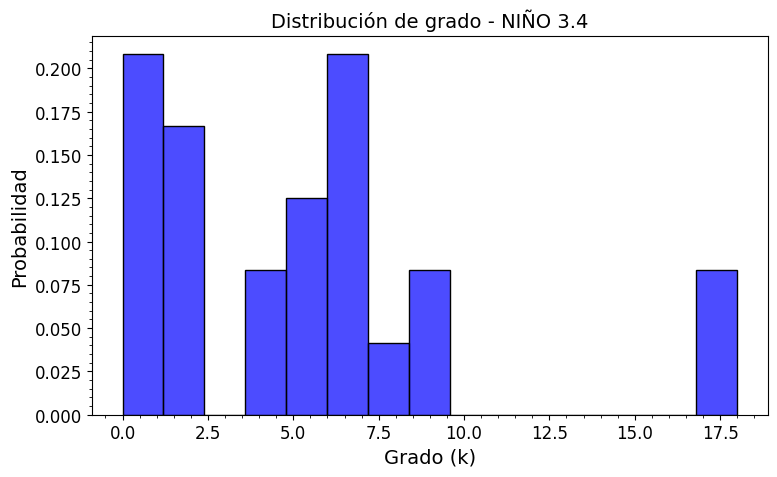

Distribución de grado - NIÑO 3.4
  Estadísticas: media=5.1667, varianza=22.4058, asimetría=1.3234, curtosis=1.5908
  Segundo momento ⟨k²⟩ = 48.1667
  Exponente γ = 2.5117 ± 0.3903 (xmin = 4.0)
  p-valor (vs. exponencial) = 0.1325
  Grado mínimo: 0, máximo: 18



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


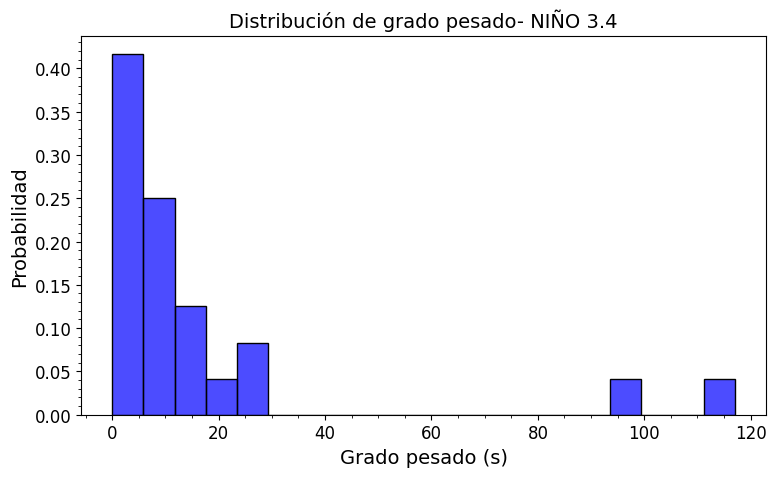

Distribución de grado pesado - NIÑO 3.4
  Estadísticas: media=16.4167, varianza=827.5580, asimetría=2.7033, curtosis=6.2188
  Segundo momento ⟨s²⟩ = 1062.5833
  Exponente γ = 2.2103 ± 0.3357 (xmin = 8.0)
  p-valor (vs. exponencial) = 0.0690
  Fuerza mínima: 0.00, máxima: 117.00



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


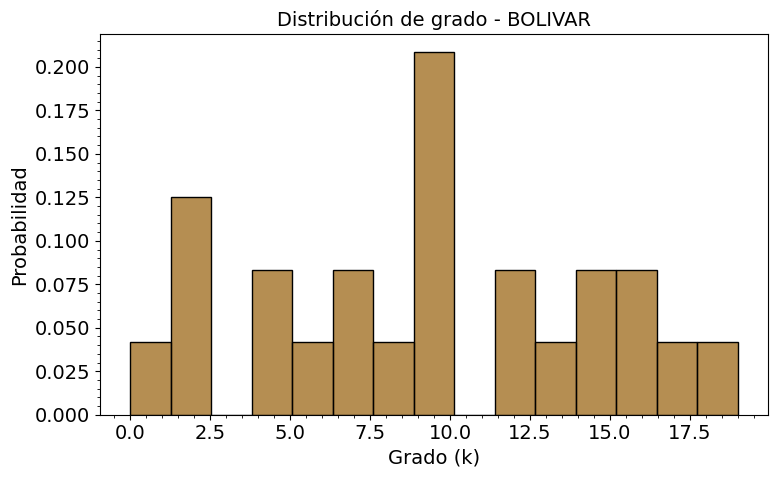

Distribución de grado - BOLIVAR
  Estadísticas: media=9.3333, varianza=27.9710, asimetría=0.0071, curtosis=-0.9393
  Segundo momento ⟨k²⟩ = 113.9167
  Exponente γ = 2.7940 ± 0.4351 (xmin = 7.0)
  p-valor (vs. exponencial) = 0.0023
  Grado mínimo: 0, máximo: 19



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


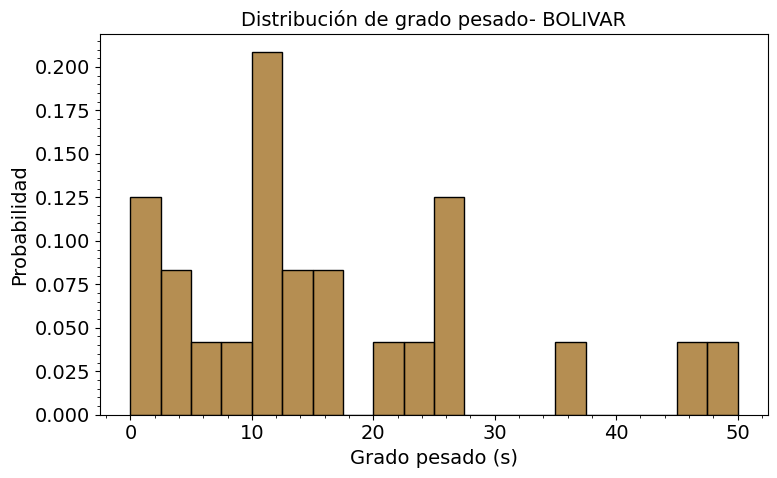

Distribución de grado pesado - BOLIVAR
  Estadísticas: media=16.4167, varianza=175.0362, asimetría=1.0643, curtosis=0.5078
  Segundo momento ⟨s²⟩ = 437.2500
  Exponente γ = 2.5635 ± 0.3792 (xmin = 10.0)
  p-valor (vs. exponencial) = 0.6680
  Fuerza mínima: 0.00, máxima: 50.00



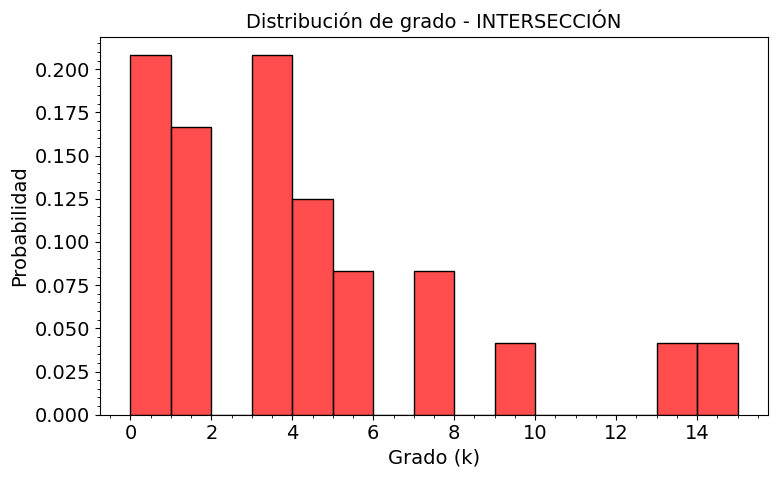

Distribución de grado - INTERSECCIÓN
  Estadísticas: media=3.8333, varianza=15.9710, asimetría=1.3860, curtosis=1.4229
  Segundo momento ⟨k²⟩ = 30.0000
  Exponente γ = 2.4822 ± 0.3827 (xmin = 3.0)
  p-valor (vs. exponencial) = 0.7798
  Grado mínimo: 0, máximo: 15



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


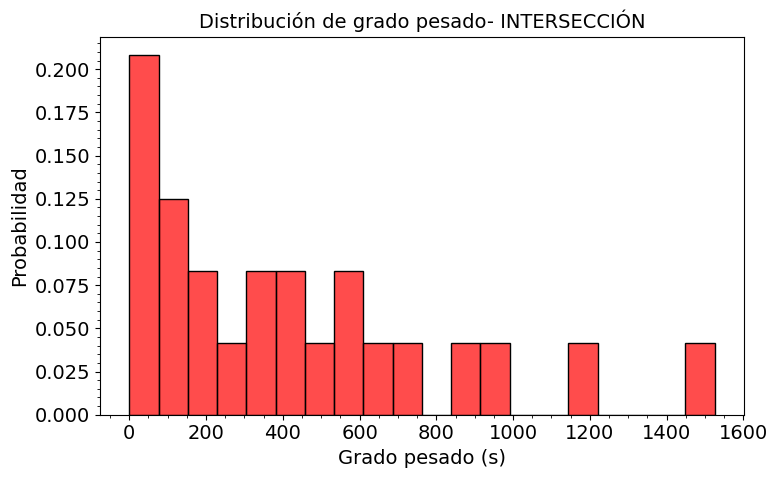

Distribución de grado pesado - INTERSECCIÓN
  Estadísticas: media=421.1900, varianza=169783.1186, asimetría=1.0362, curtosis=0.4656
  Segundo momento ⟨s²⟩ = 340109.8550
  Exponente γ = 2.9337 ± 0.5830 (xmin = 425.0)
  p-valor (vs. exponencial) = 0.5115
  Fuerza mínima: 0.00, máxima: 1525.00



In [39]:
# Suponiendo que tienes G, G1 y GC definidos
plot_degree_distribution(G, "NIÑO 3.4", color='blue', bins=15, loglog=False)
plot_degree_distribution_pesada(G, "NIÑO 3.4", color='blue', bins=20, loglog=False)

plot_degree_distribution(G1, "BOLIVAR", color='#965f09', bins=15, loglog=False)
plot_degree_distribution_pesada(G1, "BOLIVAR", color='#965f09', bins=20, loglog=False)

plot_degree_distribution(GC, "INTERSECCIÓN", color='red', bins=15, loglog=False)
plot_degree_distribution_pesada(GC, "INTERSECCIÓN", color='red', bins=20, loglog=False)

##PEARSON

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def correlacion_pearson(x, y, nombre_x='Serie X', nombre_y='Serie Y'):
    """
    Calcula la correlación de Pearson entre dos series y genera una gráfica de dispersión.

    Parámetros:
    x, y : listas o arrays unidimensionales de la misma longitud.
    nombre_x, nombre_y : etiquetas para los ejes.

    Retorna:
    r : coeficiente de correlación de Pearson.
    p : valor p asociado.
    """
    x = np.array(x)
    y = np.array(y)
    if len(x) != len(y):
        raise ValueError("Las series deben tener la misma longitud")

    # Calcular correlación de Pearson
    r, p = stats.pearsonr(x, y)

    # Ajuste lineal para la recta de regresión
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Crear gráfica
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, alpha=0.6, edgecolors='k', linewidth=0.5)
    # Recta de regresión
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, 'r-', label=f'Regresión lineal (r={r:.3f})')
    plt.xlabel(nombre_x)
    plt.ylabel(nombre_y)
    #plt.title(f'Correlación de Pearson: r={r:.3f}, p={p:.3e}')
    #plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})
    plt.show()

    print(f"Coeficiente de correlación de Pearson: r = {r:.4f}")
    print(f"Valor p: {p:.4e}")
    return r, p

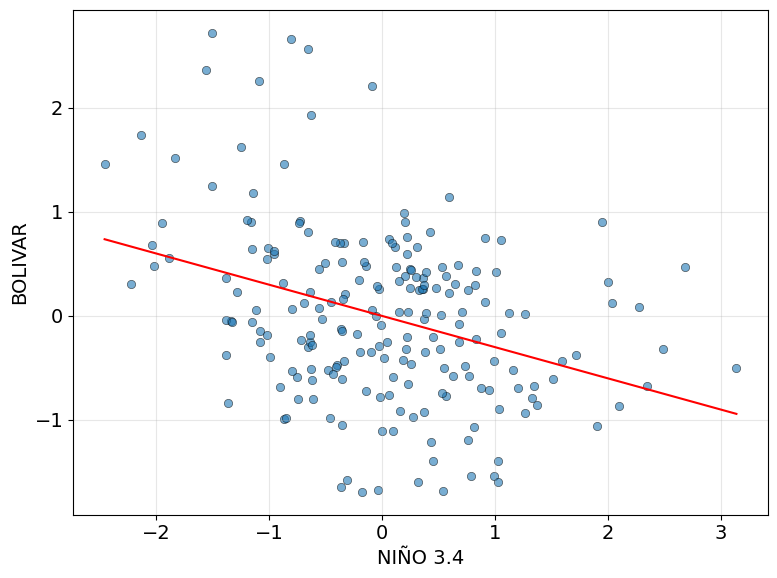

Coeficiente de correlación de Pearson: r = -0.3503
Valor p: 2.8055e-07


In [41]:
# Suponiendo que tienes las series x (NIÑO) y x1 (CALAMAR) definidas
r, p = correlacion_pearson(x1, x, nombre_y='BOLIVAR', nombre_x='NIÑO 3.4')

##BOOTSTRAP

In [42]:
porcentaje_para_comparar=promedio_corregido
print(porcentaje_para_comparar)

21.88000104256262


Promedio corregido observado (x1 original): 37.84 %

Resultados del bootstrap clásico (promedio corregido, 1000 remuestras):
Media: 31.67
Mediana: 31.02
Desviación estándar: 8.96
Intervalo de confianza 95%: (16.02, 50.51)
Valor observado: 37.84


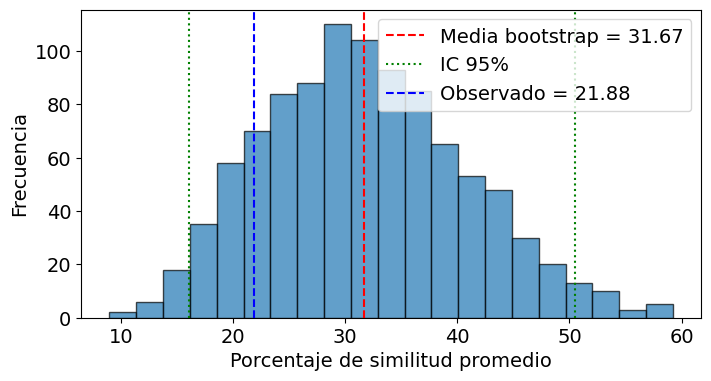

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx   # por si acaso, aunque ya debería estar importado

# -------------------------------------------------------------------
# Definir la función para promedio ignorando nodos
# -------------------------------------------------------------------
def promedio_sin_nodos(matriz, nodos_ignorar):
    """
    Calcula el promedio de la parte triangular superior de la matriz,
    excluyendo las entradas que involucren los nodos especificados.
    """
    n = matriz.shape[0]  # debería ser 24
    nodos_validos = np.ones(n, dtype=bool)
    nodos_validos[nodos_ignorar] = False
    triu_mask = np.triu(np.ones((n, n), dtype=bool))
    mask = triu_mask & nodos_validos[None, :] & nodos_validos[:, None]
    return matriz[mask].mean()

# -------------------------------------------------------------------
# Parámetros del bootstrap
# -------------------------------------------------------------------
w_opt = 4
n_bootstrap = 1000                # número de remuestras
nodos_ignorar = [4, 13, 19]       # según tu análisis
np.random.seed(42)                 # para reproducibilidad

# Asegurarse de que A (matriz del niño) está calculada (si no, calcúlala)
# nodos_x = crear_ind(x, w_opt)
# G_x, _, _ = crear_grafo(nodos_x, w_opt)
# A = nx.to_numpy_array(G_x, dtype=int)

# -------------------------------------------------------------------
# Valor observado con la serie original x1 (sin remuestrear)
# -------------------------------------------------------------------
# Calcular la matriz de x1 original (A1_orig) si no la tienes
nodos_x1_orig = crear_ind(x1, w_opt)
G_x1_orig, _, _ = crear_grafo(nodos_x1_orig, w_opt)
A1_orig = nx.to_numpy_array(G_x1_orig, dtype=int)

# Calcular C_clean para la serie original
with np.errstate(divide='ignore', invalid='ignore'):
    C_orig = np.divide(A, A1_orig, out=np.zeros_like(A, dtype=float), where=A1_orig != 0) * 100
C_orig_clean = np.where(np.isinf(C_orig), 0, C_orig)
promedio_obs = promedio_sin_nodos(C_orig_clean, nodos_ignorar)

print(f"Promedio corregido observado (x1 original): {promedio_obs:.2f} %")

# -------------------------------------------------------------------
# Bootstrap clásico sobre x1
# -------------------------------------------------------------------
porcents_boot_corr = []

for i in range(n_bootstrap):
    # 1. Remuestrear x1 con reemplazo
    indices_boot = np.random.choice(len(x1), size=len(x1), replace=True)
    if isinstance(x1, list):
        x1_boot = [x1[i] for i in indices_boot]
    else:  # asumimos array de numpy
        x1_boot = x1[indices_boot]

    # 2. Obtener patrones ordinales y matriz de la remuestra
    nodos_boot = crear_ind(x1_boot, w_opt)
    G_boot, _, _ = crear_grafo(nodos_boot, w_opt)
    A_boot = nx.to_numpy_array(G_boot, dtype=int)

    # 3. Calcular matriz de comparación con A (niño)
    with np.errstate(divide='ignore', invalid='ignore'):
        C = np.divide(A, A_boot, out=np.zeros_like(A, dtype=float), where=A_boot != 0) * 100
    C_clean = np.where(np.isinf(C), 0, C)

    # 4. Promedio corregido ignorando nodos
    prom_corr = promedio_sin_nodos(C_clean, nodos_ignorar)
    porcents_boot_corr.append(prom_corr)

porcents_boot_corr = np.array(porcents_boot_corr)

# -------------------------------------------------------------------
# Resultados bootstrap
# -------------------------------------------------------------------
media_boot = np.mean(porcents_boot_corr)
mediana_boot = np.median(porcents_boot_corr)
desv_boot = np.std(porcents_boot_corr, ddof=1)
ic_inf = np.percentile(porcents_boot_corr, 2.5)
ic_sup = np.percentile(porcents_boot_corr, 97.5)

print(f"\nResultados del bootstrap clásico (promedio corregido, {n_bootstrap} remuestras):")
print(f"Media: {media_boot:.2f}")
print(f"Mediana: {mediana_boot:.2f}")
print(f"Desviación estándar: {desv_boot:.2f}")
print(f"Intervalo de confianza 95%: ({ic_inf:.2f}, {ic_sup:.2f})")
print(f"Valor observado: {promedio_obs:.2f}")

# Histograma
plt.figure(figsize=(8,4))
plt.hist(porcents_boot_corr, bins='auto', alpha=0.7, edgecolor='black')
plt.axvline(media_boot, color='red', linestyle='--', label=f'Media bootstrap = {media_boot:.2f}')
plt.axvline(ic_inf, color='green', linestyle=':', label='IC 95%')
plt.axvline(ic_sup, color='green', linestyle=':')
plt.axvline(porcentaje_para_comparar, color='blue', linestyle='--', label=f'Observado = {porcentaje_para_comparar:.2f}')
#plt.title('Distribución bootstrap del promedio corregido (ignorando nodos)')
plt.xlabel('Porcentaje de similitud promedio')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

Promedio corregido observado (x1 original): 37.84 %

Resultados del bootstrap clásico (promedio corregido, 1000 remuestras):
Media: 31.67
Mediana: 31.02
Desviación estándar: 8.96
Intervalo de confianza 95%: (16.02, 50.51)
Valor observado: 37.84
Distancia del observado respecto a la media bootstrap: -1.09 desviaciones estándar


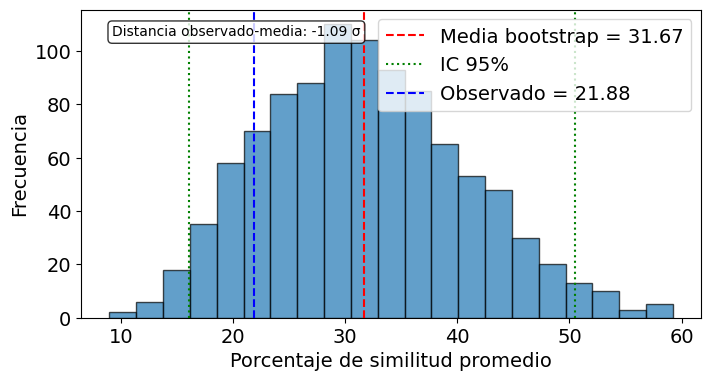

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx   # por si acaso, aunque ya debería estar importado

# -------------------------------------------------------------------
# Definir la función para promedio ignorando nodos
# -------------------------------------------------------------------
def promedio_sin_nodos(matriz, nodos_ignorar):
    """
    Calcula el promedio de la parte triangular superior de la matriz,
    excluyendo las entradas que involucren los nodos especificados.
    """
    n = matriz.shape[0]  # debería ser 24
    nodos_validos = np.ones(n, dtype=bool)
    nodos_validos[nodos_ignorar] = False
    triu_mask = np.triu(np.ones((n, n), dtype=bool))
    mask = triu_mask & nodos_validos[None, :] & nodos_validos[:, None]
    return matriz[mask].mean()

# -------------------------------------------------------------------
# Parámetros del bootstrap
# -------------------------------------------------------------------
w_opt = 4
n_bootstrap = 1000                # número de remuestras
nodos_ignorar = [4, 13, 19]       # según tu análisis
np.random.seed(42)                 # para reproducibilidad

# Asegurarse de que A (matriz del niño) está calculada (si no, calcúlala)
# nodos_x = crear_ind(x, w_opt)
# G_x, _, _ = crear_grafo(nodos_x, w_opt)
# A = nx.to_numpy_array(G_x, dtype=int)

# -------------------------------------------------------------------
# Valor observado con la serie original x1 (sin remuestrear)
# -------------------------------------------------------------------
# Calcular la matriz de x1 original (A1_orig) si no la tienes
nodos_x1_orig = crear_ind(x1, w_opt)
G_x1_orig, _, _ = crear_grafo(nodos_x1_orig, w_opt)
A1_orig = nx.to_numpy_array(G_x1_orig, dtype=int)

# Calcular C_clean para la serie original
with np.errstate(divide='ignore', invalid='ignore'):
    C_orig = np.divide(A, A1_orig, out=np.zeros_like(A, dtype=float), where=A1_orig != 0) * 100
C_orig_clean = np.where(np.isinf(C_orig), 0, C_orig)
promedio_obs = promedio_sin_nodos(C_orig_clean, nodos_ignorar)

print(f"Promedio corregido observado (x1 original): {promedio_obs:.2f} %")

# -------------------------------------------------------------------
# Bootstrap clásico sobre x1
# -------------------------------------------------------------------
porcents_boot_corr = []

for i in range(n_bootstrap):
    # 1. Remuestrear x1 con reemplazo
    indices_boot = np.random.choice(len(x1), size=len(x1), replace=True)
    if isinstance(x1, list):
        x1_boot = [x1[i] for i in indices_boot]
    else:  # asumimos array de numpy
        x1_boot = x1[indices_boot]

    # 2. Obtener patrones ordinales y matriz de la remuestra
    nodos_boot = crear_ind(x1_boot, w_opt)
    G_boot, _, _ = crear_grafo(nodos_boot, w_opt)
    A_boot = nx.to_numpy_array(G_boot, dtype=int)

    # 3. Calcular matriz de comparación con A (niño)
    with np.errstate(divide='ignore', invalid='ignore'):
        C = np.divide(A, A_boot, out=np.zeros_like(A, dtype=float), where=A_boot != 0) * 100
    C_clean = np.where(np.isinf(C), 0, C)

    # 4. Promedio corregido ignorando nodos
    prom_corr = promedio_sin_nodos(C_clean, nodos_ignorar)
    porcents_boot_corr.append(prom_corr)

porcents_boot_corr = np.array(porcents_boot_corr)

# -------------------------------------------------------------------
# Resultados bootstrap
# -------------------------------------------------------------------
media_boot = np.mean(porcents_boot_corr)
mediana_boot = np.median(porcents_boot_corr)
desv_boot = np.std(porcents_boot_corr, ddof=1)
ic_inf = np.percentile(porcents_boot_corr, 2.5)
ic_sup = np.percentile(porcents_boot_corr, 97.5)

# Distancia del valor observado respecto a la media bootstrap (en desviaciones estándar)
distancia_sd = (porcentaje_para_comparar - media_boot) / desv_boot

print(f"\nResultados del bootstrap clásico (promedio corregido, {n_bootstrap} remuestras):")
print(f"Media: {media_boot:.2f}")
print(f"Mediana: {mediana_boot:.2f}")
print(f"Desviación estándar: {desv_boot:.2f}")
print(f"Intervalo de confianza 95%: ({ic_inf:.2f}, {ic_sup:.2f})")
print(f"Valor observado: {promedio_obs:.2f}")
print(f"Distancia del observado respecto a la media bootstrap: {distancia_sd:.2f} desviaciones estándar")

# Histograma
plt.figure(figsize=(8,4))
plt.hist(porcents_boot_corr, bins='auto', alpha=0.7, edgecolor='black')
plt.axvline(media_boot, color='red', linestyle='--', label=f'Media bootstrap = {media_boot:.2f}')
plt.axvline(ic_inf, color='green', linestyle=':', label='IC 95%')
plt.axvline(ic_sup, color='green', linestyle=':')
plt.axvline(porcentaje_para_comparar, color='blue', linestyle='--', label=f'Observado = {porcentaje_para_comparar:.2f}')

# Agregar anotación con la distancia en SD (opción con recuadro)
plt.text(0.05, 0.95, f'Distancia observado-media: {distancia_sd:.2f} σ',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlabel('Porcentaje de similitud promedio')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()


  Red: Niño 3.4  (n = 20 nodos activos)
  x̂_min  = 10.0
  α̂      = 2.1752  ±  0.3716  (1σ)
  KS obs = 0.1282
  n_tail = 10  (puntos en la cola de ley de potencias)
  p-valor MC (2500 sims) = 0.867  →  ley de potencias PLAUSIBLE  ✓
  (Regla del paper: rechazar si p ≤ 0.1)

  Red: Caudal Óbidos  (n = 23 nodos activos)
  x̂_min  = 10.0
  α̂      = 2.5635  ±  0.3792  (1σ)
  KS obs = 0.1791
  n_tail = 17  (puntos en la cola de ley de potencias)
  p-valor MC (2500 sims) = 0.258  →  ley de potencias PLAUSIBLE  ✓
  (Regla del paper: rechazar si p ≤ 0.1)


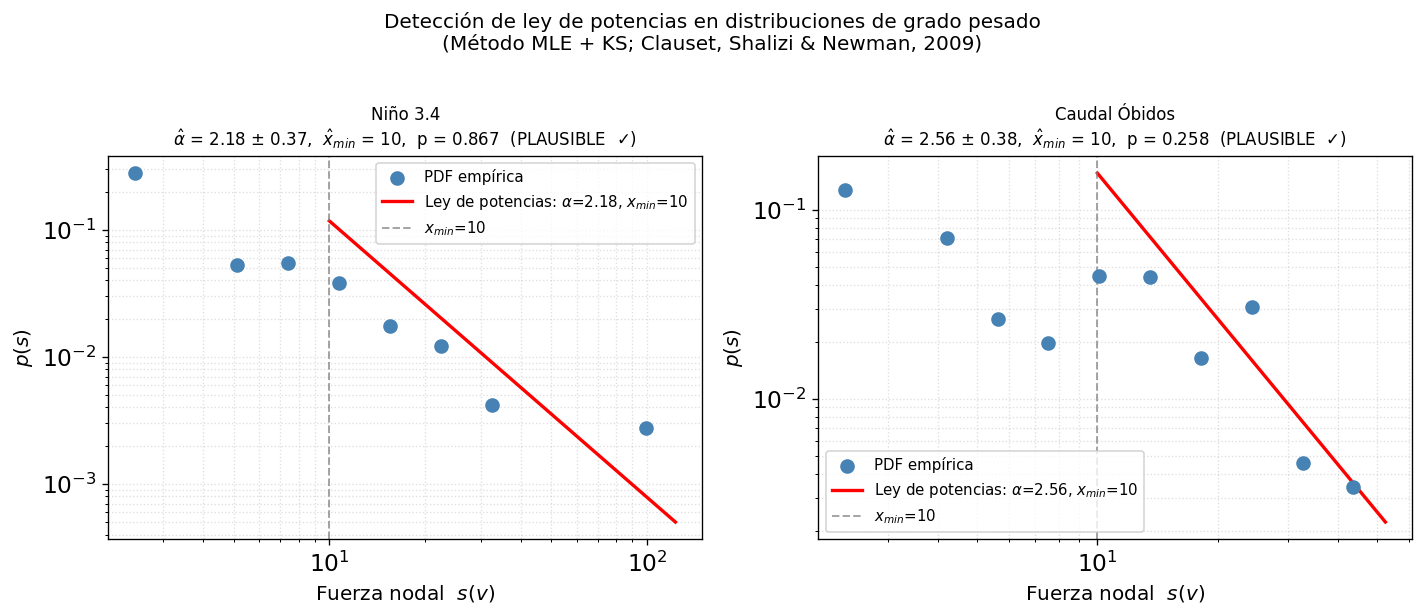


  RESUMEN COMPARATIVO
Métrica                       Niño 3.4       Óbidos
-------------------------------------------------------
  x̂_min                            10           10
  α̂                            2.1752       2.5635
  σ(α̂)                         0.3716       0.3792
  KS                            0.1282       0.1791
  n_tail                            10           17
  p-valor MC                    0.8672       0.2580

Criterio: p > 0.1  →  ley de potencias plausible
          p ≤ 0.1  →  ley de potencias rechazada


In [45]:
# ============================================================
# DETECCIÓN DE LEY DE POTENCIAS EN DISTRIBUCIONES DE GRADO PESADO
# Método: PDF con ajuste MLE (Clauset, Shalizi & Newman, 2009)
# Sección 3 + Sección 4 del paper
# ============================================================
#
# El paper advierte que el método más común —trazar el histograma
# en escala log-log y ajustar por regresión lineal (LS)— produce
# estimaciones sistemáticamente sesgadas de α (ver Tabla 3.1).
# El enfoque correcto es:
#   1. Estimar x_min con el estadístico KS (Ec. 3.9).
#   2. Estimar α con el MLE continuo (Ec. 3.1) o discreto (Ec. 3.7).
#   3. Calcular la bondad de ajuste mediante Monte Carlo (Sección 4).
#   4. Visualizar la PDF en escala log-log junto con el ajuste.
#
# Aquí la "distribución de grado pesado" es la distribución de
# FUERZAS nodales s(v) = Σ_u w(v,u) en cada red de partición ordinal.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import zeta as hurwitz_zeta   # ζ(α, x_min)
from scipy.optimize import minimize_scalar

# ------------------------------------------------------------------
# 0. Extraer fuerzas nodales de los grafos G y G1
# ------------------------------------------------------------------
fuerzas_nino  = np.array([d for _, d in G.degree(weight='weight')],  dtype=float)
fuerzas_obidos = np.array([d for _, d in G1.degree(weight='weight')], dtype=float)

# Excluir nodos aislados (fuerza = 0) que no aportan información de escala
fuerzas_nino   = fuerzas_nino[fuerzas_nino > 0]
fuerzas_obidos = fuerzas_obidos[fuerzas_obidos > 0]

# ------------------------------------------------------------------
# 1. Herramientas estadísticas (Clauset et al., 2009)
# ------------------------------------------------------------------

def mle_alpha_continuo(data, xmin):
    """
    Estimador de máxima verosimilitud para α en distribución de
    ley de potencias continua (Ec. 3.1 del paper):
        α̂ = 1 + n [Σ ln(x_i / x_min)]^{-1}
    Equivalente al estimador de Hill (asintóticamente normal y consistente).
    """
    x = data[data >= xmin]
    n = len(x)
    if n < 2:
        return np.nan
    alpha = 1.0 + n / np.sum(np.log(x / xmin))
    return alpha

def error_estandar_alpha(alpha, n):
    """
    Error estándar del MLE (Ec. 3.2):  σ = (α̂ - 1) / √n
    """
    return (alpha - 1.0) / np.sqrt(n)

def ks_distancia(data, xmin, alpha):
    """
    Estadístico KS entre la CDF empírica y la CDF teórica de la ley
    de potencias continua (Ec. 3.9):  D = max_{x ≥ x_min} |S(x) - P(x)|
    donde P(x) = (x / x_min)^{-α+1}
    """
    x = np.sort(data[data >= xmin])
    n = len(x)
    if n == 0:
        return np.inf
    # CDF empírica S(x): fracción de datos ≥ cada valor observado
    S = 1.0 - np.arange(n) / n          # S(x_i) = (n-i)/n  (complementaria)
    # CDF teórica P(x) = (x / x_min)^{-α+1}
    P = (x / xmin) ** (-alpha + 1.0)
    P = np.clip(P, 0.0, 1.0)
    return np.max(np.abs(S - P))

def estimar_xmin_ks(data):
    """
    Selecciona x̂_min minimizando el estadístico KS sobre todos los
    candidatos únicos (método de Clauset et al., Sec. 3.3).
    Devuelve (x_min_opt, alpha_opt, D_min).
    """
    candidatos = np.unique(data)
    # No tiene sentido probar los dos últimos valores (quedarían < 2 puntos)
    candidatos = candidatos[:-2] if len(candidatos) > 2 else candidatos

    mejor_D     = np.inf
    mejor_xmin  = candidatos[0]
    mejor_alpha = np.nan

    for xc in candidatos:
        alpha = mle_alpha_continuo(data, xc)
        if np.isnan(alpha) or alpha <= 1.0:
            continue
        D = ks_distancia(data, xc, alpha)
        if D < mejor_D:
            mejor_D     = D
            mejor_xmin  = xc
            mejor_alpha = alpha

    return mejor_xmin, mejor_alpha, mejor_D

def pvalor_montecarlo(data, xmin, alpha, n_sims=2500, seed=42):
    """
    Calcula el p-valor por Monte Carlo (Sección 4 del paper).
    Genera n_sims conjuntos sintéticos semiparam. y cuenta cuántas veces
    su KS supera el observado.
    Regla del paper: p > 0.1 → ley de potencias plausible.
    """
    rng = np.random.default_rng(seed)
    n_total  = len(data)
    n_tail   = int(np.sum(data >= xmin))
    n_body   = n_total - n_tail
    datos_body = data[data < xmin]

    D_obs = ks_distancia(data, xmin, alpha)

    cuenta = 0
    for _ in range(n_sims):
        # Generar cola sintética: x = x_min * u^{-1/(α-1)}  (Apéndice D, Ec. D.4)
        u     = rng.uniform(0, 1, n_tail)
        cola  = xmin * (1.0 - u) ** (-1.0 / (alpha - 1.0))

        # Cuerpo: remuestreo con reemplazo de los datos empíricos por debajo de x_min
        if n_body > 0:
            cuerpo = rng.choice(datos_body, size=n_body, replace=True)
            sintetico = np.concatenate([cola, cuerpo])
        else:
            sintetico = cola

        # Ajustar ley de potencias al conjunto sintético
        alpha_s = mle_alpha_continuo(sintetico, xmin)
        if np.isnan(alpha_s) or alpha_s <= 1.0:
            continue
        D_s = ks_distancia(sintetico, xmin, alpha_s)
        if D_s >= D_obs:
            cuenta += 1

    return cuenta / n_sims

def pdf_powerlaw_continua(x, xmin, alpha):
    """
    PDF de la ley de potencias continua (Ec. 2.2):
        p(x) = (α-1)/x_min * (x/x_min)^{-α}    para x ≥ x_min
    """
    p = np.zeros_like(x, dtype=float)
    mask = x >= xmin
    p[mask] = (alpha - 1.0) / xmin * (x[mask] / xmin) ** (-alpha)
    return p

# ------------------------------------------------------------------
# 2. Ajuste y diagnóstico para cada red
# ------------------------------------------------------------------

def analizar_distribucion(fuerzas, nombre, n_sims=2500, ax=None):
    """
    Aplica el método completo de Clauset et al. (2009) a un array
    de fuerzas nodales e imprime resultados.  Dibuja en ax si se pasa.
    """
    print(f"\n{'='*55}")
    print(f"  Red: {nombre}  (n = {len(fuerzas)} nodos activos)")
    print(f"{'='*55}")

    # --- Paso 1: estimar x_min y α ---
    xmin, alpha, D_obs = estimar_xmin_ks(fuerzas)
    n_tail = int(np.sum(fuerzas >= xmin))
    sigma  = error_estandar_alpha(alpha, n_tail)

    print(f"  x̂_min  = {xmin:.1f}")
    print(f"  α̂      = {alpha:.4f}  ±  {sigma:.4f}  (1σ)")
    print(f"  KS obs = {D_obs:.4f}")
    print(f"  n_tail = {n_tail}  (puntos en la cola de ley de potencias)")

    # --- Paso 2: bondad de ajuste por Monte Carlo ---
    # Precisión ~0.02 con 2500 simulaciones (ver Sec. 4.1 del paper)
    p = pvalor_montecarlo(fuerzas, xmin, alpha, n_sims=n_sims)
    veredicto = "PLAUSIBLE  ✓" if p > 0.1 else "RECHAZADA  ✗"
    print(f"  p-valor MC ({n_sims} sims) = {p:.3f}  →  ley de potencias {veredicto}")
    print(f"  (Regla del paper: rechazar si p ≤ 0.1)")

    # --- Paso 3: visualización PDF en escala log-log ---
    if ax is not None:
        # Histograma logarítmico (logarithmic binning) de la PDF empírica
        # Evita el sesgo de bins de ancho constante (ver Apéndice A del paper)
        datos_pos = fuerzas[fuerzas > 0]
        log_min = np.log10(datos_pos.min())
        log_max = np.log10(datos_pos.max())
        bins = np.logspace(log_min, log_max, num=12)

        counts, edges = np.histogram(datos_pos, bins=bins)
        widths   = np.diff(edges)
        centers  = 0.5 * (edges[:-1] + edges[1:])
        pdf_emp  = counts / (len(datos_pos) * widths)   # densidad normalizada

        mask_pos = counts > 0
        ax.scatter(centers[mask_pos], pdf_emp[mask_pos],
                   color='steelblue', s=60, zorder=3, label='PDF empírica')

        # Curva teórica de ley de potencias para x ≥ x_min
        x_fit = np.linspace(xmin, datos_pos.max() * 1.05, 300)
        y_fit = pdf_powerlaw_continua(x_fit, xmin, alpha)
        # Escalar para que la integral sobre el rango observado coincida
        # La normalización ya es correcta desde Ec. 2.2
        ax.plot(x_fit, y_fit, 'r-', lw=2,
                label=rf'Ley de potencias: $\alpha$={alpha:.2f}, $x_{{min}}$={xmin:.0f}')

        # Línea vertical en x_min
        ax.axvline(xmin, color='gray', ls='--', lw=1.2, alpha=0.7, label=f'$x_{{min}}$={xmin:.0f}')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Fuerza nodal  $s(v)$', fontsize=12)
        ax.set_ylabel('$p(s)$', fontsize=12)
        ax.set_title(f'{nombre}\n'
                     rf'$\hat{{\alpha}}$ = {alpha:.2f} ± {sigma:.2f},  '
                     rf'$\hat{{x}}_{{min}}$ = {xmin:.0f},  '
                     f'p = {p:.3f}  ({veredicto})',
                     fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, which='both', ls=':', alpha=0.4)

    return dict(xmin=xmin, alpha=alpha, sigma=sigma, D=D_obs,
                p=p, n_tail=n_tail)

# ------------------------------------------------------------------
# 3. Ejecutar análisis para las dos redes
# ------------------------------------------------------------------

plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 11,
    'figure.dpi': 120
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    'Detección de ley de potencias en distribuciones de grado pesado\n'
    '(Método MLE + KS; Clauset, Shalizi & Newman, 2009)',
    fontsize=12, y=1.02
)

res_nino   = analizar_distribucion(fuerzas_nino,   "Niño 3.4",     n_sims=2500, ax=axes[0])
res_obidos = analizar_distribucion(fuerzas_obidos, "Caudal Óbidos", n_sims=2500, ax=axes[1])

plt.tight_layout()
plt.savefig("powerlaw_grado_pesado.png", dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# 4. Tabla resumen comparativa
# ------------------------------------------------------------------
print("\n" + "="*55)
print("  RESUMEN COMPARATIVO")
print("="*55)
print(f"{'Métrica':<25} {'Niño 3.4':>12} {'Óbidos':>12}")
print("-"*55)
for key, label in [('xmin',   'x̂_min'),
                   ('alpha',  'α̂'),
                   ('sigma',  'σ(α̂)'),
                   ('D',      'KS'),
                   ('n_tail', 'n_tail'),
                   ('p',      'p-valor MC')]:
    v1 = res_nino[key]
    v2 = res_obidos[key]
    if key in ('xmin', 'n_tail'):
        s1 = f"{v1:.0f}"
        s2 = f"{v2:.0f}"
    else:
        s1 = f"{v1:.4f}"
        s2 = f"{v2:.4f}"
    print(f"  {label:<23} {s1:>12} {s2:>12}")
print("="*55)
print("\nCriterio: p > 0.1  →  ley de potencias plausible")
print("          p ≤ 0.1  →  ley de potencias rechazada")